# Creating data frames for looking at the IL17 gene locus

## RNAseq data frame for IL17 gene expression

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq.head()

In [ ]:
RNA_seq_IL17 = RNA_seq[
    (RNA_seq["Unnamed: 0"] == "Il17a") | 
    (RNA_seq["Unnamed: 0"] == "Il17b") |
    (RNA_seq["Unnamed: 0"] == "Il17c") |
    (RNA_seq["Unnamed: 0"] == "Il17d") |
    (RNA_seq["Unnamed: 0"] == "Il17f")
    ]
RNA_seq_IL17
mean_IL17_exp = RNA_seq_IL17.iloc[:, 1:].mean()
top10_IL17_exp = mean_IL17_exp.nlargest(10)
print(top10_IL17_exp)



In [ ]:
RNA_seq_IL17.to_csv('data/RNA_seq_IL17.csv', index=False, header=True)
RNA_seq_IL17_check = pd.read_csv('data/RNA_seq_IL17.csv')
RNA_seq_IL17_check

In [ ]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]


RNA_seq_gd_IL17 = RNA_seq_IL17[Tgd_cells].copy()
RNA_seq_gd_IL17.describe()

## ATAC data frame with summits 100kb from IL17 locus

In [ ]:
ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')
ATAC_seq.head()

In [ ]:
ATAC_seq_IL17 = ATAC_seq[ATAC_seq['genes.within.100Kb'].str.contains('Il17a|Il17b|Il17c|Il17d|Il17f', case=False, na=False)].copy()
ATAC_seq_IL17

In [ ]:
ATAC_seq_IL17.to_csv('data/ATAC_seq_IL17.csv', index=False, header=True)
ATAC_seq_IL17_check = pd.read_csv('data/ATAC_seq_IL17.csv')
ATAC_seq_IL17_check

In [ ]:
ATAC_seq_gd_IL17 = pd.concat([ATAC_seq_IL17[[
        "ImmGenATAC1219.peakID",
        "chrom",
        "Summit",
        "mm10.60way.phastCons_scores",
        "_-log10_bestPvalue",
        "Included.in.systematic.analysis",
        "TSS", 
        "genes.within.100Kb"
    ]],
    ATAC_seq_IL17[Tgd_cells[1:]].copy()], axis=1)
ATAC_seq_gd_IL17

# Clustering based on RNAseq data and comparison with ATACseq based clustering

## creating RNAseq data frame with only our cell types

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
RNA_seq = pd.read_csv('data/mmc2.csv')

Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq_gd_anot = RNA_seq[Tgd_cells].copy()
RNA_seq_gd_anot.to_csv('data/RNA_seq_gd_anot.csv', index=False, header=True)
RNA_seq_gd_check = pd.read_csv('data/RNA_seq_gd_anot.csv')
RNA_seq_gd_check

,Unnamed: 0,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,0610005C13Rik,1.021812,1.022363,1.389747,1.024819,1.024482,1.026430,1.023995,1.167561,1.024819,1.023995,1.025543,1.024819,1.023995
1,0610007P14Rik,204.298358,162.641117,206.945221,209.187788,198.421365,215.056475,150.742022,174.031477,115.930664,136.200789,108.850425,102.701399,137.925015
2,0610009B22Rik,76.418169,68.070719,82.468806,89.769337,57.661619,76.399214,47.775227,44.980534,53.461136,42.439750,28.755395,21.517647,29.122837
3,0610009L18Rik,16.947354,15.450717,13.573968,14.427620,8.249482,1.683173,8.554990,8.781962,29.156630,8.937625,10.815319,10.202163,9.033355
4,0610009O20Rik,186.261464,160.246297,125.475307,155.928005,120.692893,118.433597,94.062684,113.600798,102.445617,79.315094,84.643541,106.186930,86.383381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17530,Zyx,1420.833446,1102.093601,727.291384,399.395780,248.382338,142.239852,1307.897371,686.551382,516.204555,1784.703406,1513.145053,1713.069187,1163.327571
17531,Zzef1,120.178140,145.971474,154.743640,132.590213,150.298107,132.912133,233.402516,197.191620,297.953300,309.370289,375.410042,342.058751,322.625713
17532,Zzz3,298.099129,305.759992,260.956800,249.726900,291.366650,274.503519,239.937387,242.350770,295.934847,267.547234,317.709126,350.363612,223.088909
17533,a,1.021812,1.022363,1.024462,1.374003,2.043970,1.497412,1.023995,1.022363,1.024819,1.023995,1.025543,1.024819,1.023995


## clustering with hierarchical clustering and a heatmap like with the ATACseq data

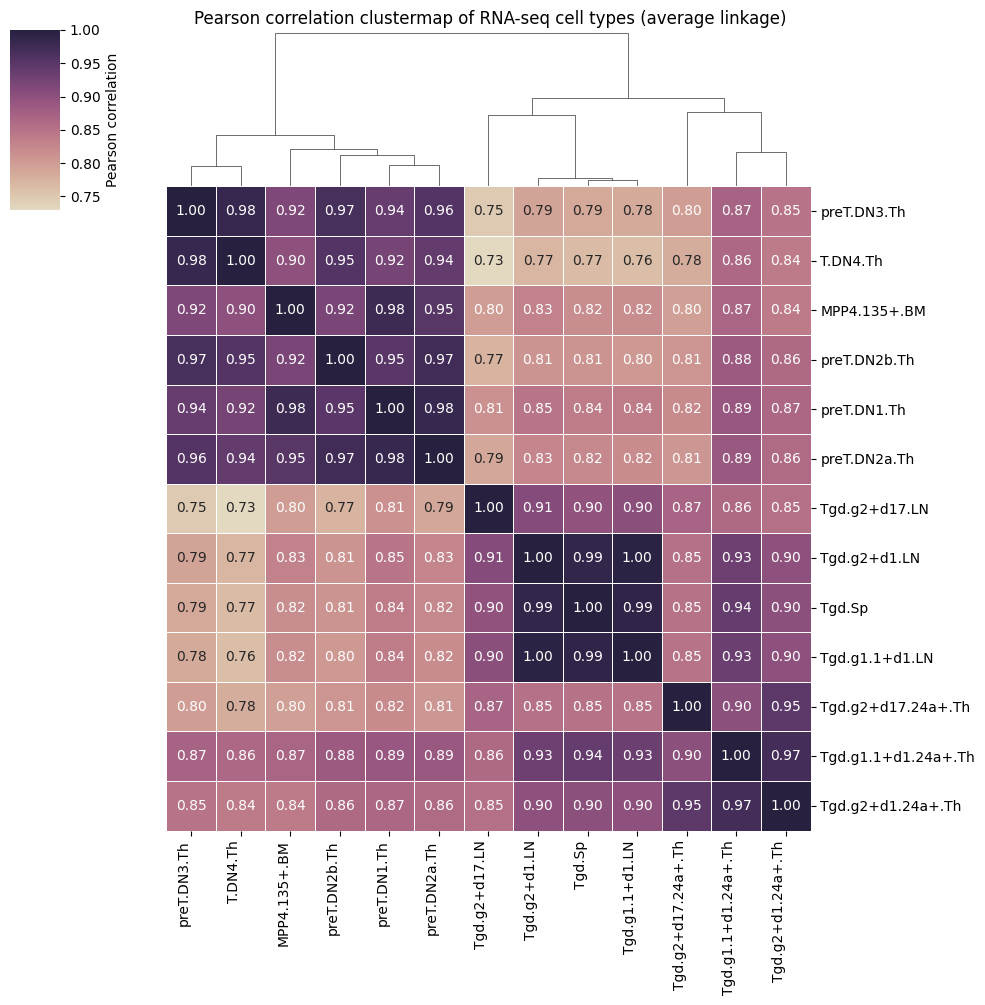

In [3]:
RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_gd_corr_matrix_pear = RNA_seq_gd[1:].corr(method='pearson')

vmin, vmax = RNA_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    RNA_gd_corr_matrix_pear,
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    center= (RNA_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of RNA-seq cell types (average linkage)', y=1)
plt.savefig('tilmann_plots/Pearson correlation clustering of RNA-seq cell types (average linkage).png', dpi=300, bbox_inches='tight')
plt.savefig('plots_for_poster/Pearson correlation clustering of RNA-seq cell types (average linkage).png', dpi=300, bbox_inches='tight')
plt.show()

- there is a very clear distinction between Tab progenitor cells and Tgd cells
- it clusters similiarly terminal differentiated cells apart from not fully differentiated
- IL17 producing cells are still quite different from others, but not as far apart as with ATAC data
- some cell types are very similar in their gene expression profile (all progenitor cell before expression of gdTCR and the terminal differentiated Tgd cells except IL17 producers)
- the differences between groups are more pronounced than with clustering based on ATAC data
    - chromation profiles seem to change more gradually during cell differentiation
    - there are clear cutoff points in the gene expression profile
        - very pronounced difference between cell types, that express the gamma delta TCR and those that do not
        - there is also quite a big differnce between fullly differentiated cells and those still developing in the thymus

## PCA, k-means clustering and Umap

### PCA

In [ ]:
RNA_seq_PCA = RNA_seq.iloc[:,8:].T.copy()
RNA_seq_PCA.columns = RNA_seq["Unnamed: 0"]
RNA_seq_PCA_gd = RNA_seq[Tgd_cells[1:]].T.copy()
RNA_seq_PCA_gd.columns = RNA_seq["Unnamed: 0"]

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = RNA_seq_PCA.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_RNA = pd.DataFrame(pcs, index=RNA_seq_PCA.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_RNA_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = RNA_seq_PCA_gd.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_RNA_gd = pd.DataFrame(pcs, index=RNA_seq_PCA_gd.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_RNA_gd_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())

In [ ]:
cells_groups = pd.read_csv('data/cells_groups.csv')

cell_group_map = {
    cell: group
    for group in cells_groups.columns
    for cell in cells_groups[group].dropna()
}

pca_RNA["cell_type"] = pca_RNA.index.map(cell_group_map).fillna("Act_T")

group_palette = {
    "gdT": "darkorchid",
    "abT": "tab:green",
    "Act_T": "tab:orange",
    "B_cells": "tab:blue",
    "Stem": "tab:red",
    "ILC": "darkslategrey",
    "MF/GN": "tab:brown",
    "Mo": "tab:pink",
    "DC": "tab:cyan",
    "Stroma": "tab:olive",
    "other": "lightgrey",
}

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_RNA_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_RNA_exp_var[1]:.1%})")
plt.title("PCA of all cell types based on RNA-seq data (PC1 vs PC2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig('tilmann_plots/PCA of all cell types based on RNA-seq data (PC1 vs PC2).png', dpi=300, bbox_inches='tight')
plt.show()

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC3",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_RNA_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_RNA_exp_var[2]:.1%})")
plt.title("PCA of all cell types based on RNA-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

- distinctions between cell groups are less clear than with ATACseq data

In [ ]:
pca_RNA_gd["sample"] = pca_RNA_gd.index

palette = dict(zip(
    pca_RNA_gd["sample"],
    sns.color_palette("viridis", n_colors=len(pca_RNA_gd))
))

sns.scatterplot(data=pca_RNA_gd, x="PC1", y="PC2", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_RNA_gd_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_RNA_gd_exp_var[1]:.1%})")
plt.title("PCA of Tgd lineage based on RNA-seq data (PC1 vs PC2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('tilmann_plots/PCA of Tgd lineage based on RNA-seq data (PC1 vs PC2).png', dpi=300, bbox_inches='tight')
plt.show()

sns.scatterplot(data=pca_RNA_gd, x="PC1", y="PC3", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_RNA_gd_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_RNA_gd_exp_var[2]:.1%})")
plt.title("PCA of Tgd lineage based on RNA-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

- Tgd cells are further apart from the Tab progenitors
    - this overlaps with the hierarchical clustering

### k-means based on PCA

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca_features = [f"PC{i+1}" for i in range(min(10, pca_RNA.shape[1]))]
X_pca = pca_RNA[pca_features].values

silhouette_scores = []
k_values = range(2, 20)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on PCA-transformed RNA data")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt = KMeans(n_clusters=best_k, random_state=42, n_init=20)
pca_RNA["kmeans_cluster"] = kmeans_opt.fit_predict(X_pca).astype(str)

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab20",
    s=100,
    alpha=0.8
)
plt.title(f"KMeans clustering on PCA of RNA data (k={best_k})")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

pca_RNA.groupby(["kmeans_cluster", "cell_type"]).size().unstack(fill_value=0)

### Umap

In [ ]:
import umap

umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)

X_raw = pca_RNA.select_dtypes(float).values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

X_umap = umap_reducer.fit_transform(X_raw_scaled)
umap_df = pd.DataFrame(
    X_umap,
    index=pca_RNA.index,
    columns=['UMAP1', 'UMAP2']
)
umap_df['cell_type'] = pca_RNA['cell_type']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='cell_type',
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.title('UMAP of all cell types based on raw RNA-seq data')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

kmeans_umap = KMeans(n_clusters=best_k, random_state=42, n_init=20)
umap_df['umap_cluster'] = kmeans_umap.fit_predict(umap_df[['UMAP1', 'UMAP2']]).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='umap_cluster',
    palette='tab20',
    s=100,
    alpha=0.8
)
plt.title(f'KMeans clusters on UMAP projection of raw RNA data (k={best_k})')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

- the clustering seperation of different cell groups with PCA and Umap based on RNAseq data is worse than with ATACseq data

# Looking at gene expression profiles

## Can genes be grouped into clusters based on their expression profiles across cell types?

### loading the RNAseq data with gene names as index

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq = pd.read_csv('data/mmc2.csv')

RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_seq_val = RNA_seq.drop(columns="Unnamed: 0").copy()
RNA_seq_val.index = RNA_seq["Unnamed: 0"]
RNA_seq_val

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0610005C13Rik,1.096732,1.096732,1.021750,1.021812,1.205236,1.326780,1.392996,1.821243,1.025543,3.383058,...,1.025785,1.025785,1.251082,1.147249,1.024462,1.019656,1.017884,1.019107,1.017884,1.024720
0610007P14Rik,206.053987,246.105317,192.424636,204.298358,189.759175,210.195155,180.219440,137.802543,139.436719,138.334965,...,121.603448,105.140895,101.841463,175.620707,280.406964,200.228029,208.171821,88.578590,129.021874,140.655763
0610009B22Rik,78.272059,78.837030,68.844751,76.418169,106.085619,77.502817,68.213092,57.224426,56.787489,40.460507,...,88.691426,73.423656,68.881268,60.811907,56.578015,100.397766,37.373080,73.888468,77.191831,84.245816
0610009L18Rik,8.577159,16.791386,15.511549,16.947354,10.583704,8.664784,2.878172,8.952120,11.873984,16.721968,...,6.132818,8.965889,4.080445,11.987408,5.627219,4.227673,2.199352,1.460090,2.482516,1.023995
0610009O20Rik,168.645852,157.926022,155.941641,186.261464,162.584556,152.088002,163.072291,133.116083,88.052982,87.408479,...,102.592399,147.139323,130.924354,107.542142,88.338330,100.779150,86.442408,193.307175,187.212720,45.464889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zyx,1077.279973,1000.129645,1441.710317,1420.833446,892.901412,591.906505,77.225695,76.893407,204.747794,84.490719,...,882.527477,895.552144,644.668492,687.226314,1022.118904,343.590422,626.708360,319.108365,340.709716,47.468741
Zzef1,182.615549,156.086051,171.910668,120.178140,169.880499,191.894767,169.235892,339.923087,320.015523,298.222997,...,265.983706,244.820391,293.192181,339.751833,302.980242,141.832817,271.207059,258.470768,178.385283,182.419304
Zzz3,271.253172,345.990082,299.982528,298.099129,234.594136,210.857607,232.421450,184.330794,181.956962,202.123436,...,148.759166,161.776889,248.030321,220.743890,217.310928,201.993028,209.141118,287.106311,216.491923,227.559035


### K-means based on expression across cell types

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gene_expr = RNA_seq_val.copy().astype(float)
X_scaled = StandardScaler().fit_transform(gene_expr)

n_components = min(10, X_scaled.shape[1], X_scaled.shape[0] - 1)
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for gene clustering on RNA_seq_gd expression profiles")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt = KMeans(n_clusters=6, random_state=42, n_init=20)
labels = kmeans_opt.fit_predict(X_pca)

gene_clusters = pd.DataFrame(
    {
        "gene": gene_expr.index,
        "kmeans_cluster": labels.astype(str),
    }
)

pca_df = pd.DataFrame(X_pca[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df["kmeans_cluster"] = gene_clusters["kmeans_cluster"].values

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=60,
    alpha=0.8,
)
ax.set_xscale("log")
ax.set_yscale("linear")
plt.title(f"KMeans gene clustering on RNA_seq_gd profiles (k={6})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

print(gene_clusters.groupby("kmeans_cluster").size().sort_values(ascending=False))


- no destinct groups can be seen
- other clustering methods could be better

#### trying out clustering of log transformed expression values

In [ ]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

In [ ]:
gene_expr_log = log_transform(RNA_seq_val).copy().astype(float)
X_scaled_log = StandardScaler().fit_transform(gene_expr_log)

n_components = min(10, X_scaled_log.shape[1], X_scaled_log.shape[0] - 1)
pca_log = PCA(n_components=n_components, random_state=42)
X_pca_log = pca_log.fit_transform(X_scaled_log)

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca_log)
    score = silhouette_score(X_pca_log, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for gene clustering on RNA_seq_gd expression profiles")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt_log = KMeans(n_clusters=7, random_state=42, n_init=20)
labels = kmeans_opt_log.fit_predict(X_pca_log)

gene_clusters_log = pd.DataFrame(
    {
        "gene": gene_expr.index,
        "kmeans_cluster": labels.astype(str),
    }
)

pca_df_log = pd.DataFrame(X_pca_log[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df_log["kmeans_cluster"] = gene_clusters_log["kmeans_cluster"].values

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=pca_df_log,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=60,
    alpha=0.8,
)
ax.set_xscale("linear")
ax.set_yscale("linear")
plt.title(f"KMeans gene clustering on RNA_seq_gd profiles (with log transformation) (k={7})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

print(gene_clusters_log.groupby("kmeans_cluster").size().sort_values(ascending=False))


#### coloring the genes in the PCA plot by their biological function (look at the scatter plot from before)

In [ ]:
import gseapy as gp

go_genesets = gp.get_library(name='GO_Biological_Process_2023', organism='Mouse')

gene2terms = {}
for term, genes in go_genesets.items():
    for gene in genes:
        gene2terms.setdefault(gene, set()).add(term)

category_keywords = {
    "housekeeping":  ["ribosom", "translation", "RNA processing",
                      "proteasome", "DNA repair", "cell cycle"],
    "immune":        ["immune", "T cell", "lymphocyte", "cytokine",
                      "interferon", "NF-kB", "antigen"],
    "metabolism":    ["metabolic", "biosynthesis", "oxidation",
                      "glycolysis", "lipid", "mitochondri"],
    "transcription": ["transcription", "chromatin", "histone", "epigenetic"],
    "signaling":     ["signaling", "kinase", "receptor", "MAPK", "PI3K"],
}

In [ ]:
def assign_category(gene):
    terms = gene2terms.get(gene.upper(), set())   
    for category, keywords in category_keywords.items():
        for t in terms:                   
            for kw in keywords:           
                if kw.lower() in t.lower():
                    return category       
    return "other"     

In [ ]:
color_map = {
    "housekeeping":  "#2196F370",  
    "immune":        "#F4433670",  
    "metabolism":    "#4CAF5070",  
    "transcription": "#FF980070",  
    "signaling":     "#9C27B070",  
    "other":         "#CCCCCC30",  
}

color_map_housekeeping = {  
    "housekeeping":  "#2196F3",  
    "immune":        "#F4433600",  
    "metabolism":    "#4CAF4F00",  
    "transcription": "#FF990000",  
    "signaling":     "#9B27B000",
    "other":         "#CCCCCC30",  
}

color_map_immune = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#F44336",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_metabolism = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#4CAF50",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_transcription = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#FF9800",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_signaling = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#9C27B0",  
    "other":         "#CCCCCC30",  
}

In [ ]:
pca_df = pd.DataFrame(X_pca[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df["gene_category"] = pca_df.index.map(assign_category)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="gene_category",
    palette=color_map_housekeeping,
    s=60,
)
plt.xscale("log")
plt.yscale("linear")
plt.title("PCA of gene expression on RNA_seq_gd profiles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="category", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()




pca_df_log = pd.DataFrame(X_pca_log[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df_log["gene_category"] = pca_df_log.index.map(assign_category)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df_log,
    x="PC1",
    y="PC2",
    hue="gene_category",
    palette=color_map_housekeeping,
    s=60,
)
plt.xscale("linear")
plt.yscale("linear")
plt.title("PCA of gene expression on RNA_seq_gd profiles (with log transformation)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="category", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()


### look at the most variable genes and where they are expressed (not used in further analysis)

#### filtering out the top 1000 most variable genes

In [ ]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq_val = RNA_seq.drop(columns="Unnamed: 0").copy()
RNA_seq_val.index = RNA_seq["Unnamed: 0"]
RNA_seq_val

In [ ]:
RNA_var_coef = RNA_seq_val.std(axis=1) / RNA_seq_val.mean(axis=1)
sns.histplot(RNA_var_coef, bins=30, kde=True)
plt.title("Histogram of RNA-seq gene expression variability (coefficient of variation)")
plt.xlabel("Coefficient of Variation")
plt.ylabel("Frequency")
plt.show()

In [ ]:
top1000_threshold = RNA_var_coef.nlargest(1000).index
rna_var_top1000 = RNA_seq_val.loc[top1000_threshold].copy()

### using Gini index to identify cell type specific genes

computing the Gini score for each gene (function was created using Claude Sonnet 4.6)
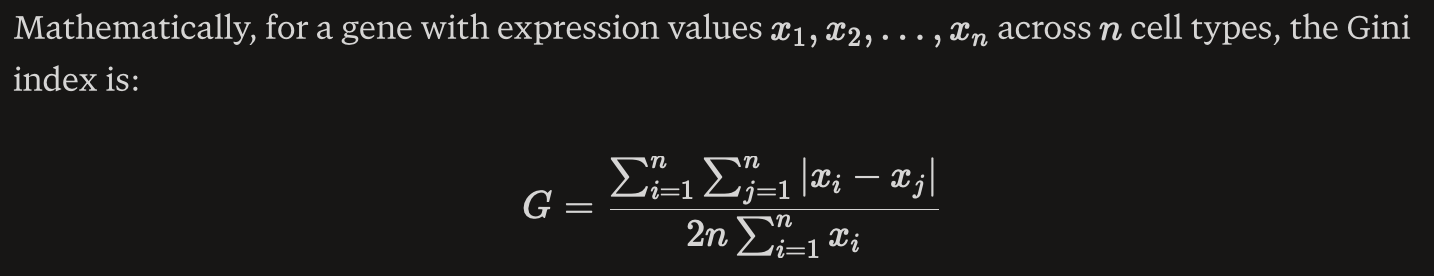

In [6]:
# --- Gini index function ---
def gini(x):
    """
    Compute the Gini coefficient for a 1D array of expression values.
    Returns a value between 0 (uniform) and 1 (fully specific).
    """
    x = np.array(x, dtype=float)
    x = x[x >= 0]           # remove negative values if any
    if x.sum() == 0:
        return 0.0           # no expression → not informative
    x = np.sort(x)           # sort ascending
    n = len(x)
    cumulative = np.cumsum(x)
    # Gini formula based on the area under the Lorenz curve
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * x.sum()) / (n * x.sum())

RNA_seq_gini = RNA_seq_val.copy()
RNA_seq_gini["gini_score"] = RNA_seq_gini.apply(gini, axis=1)

visualizing the Gini Score using a Umap of all genes

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


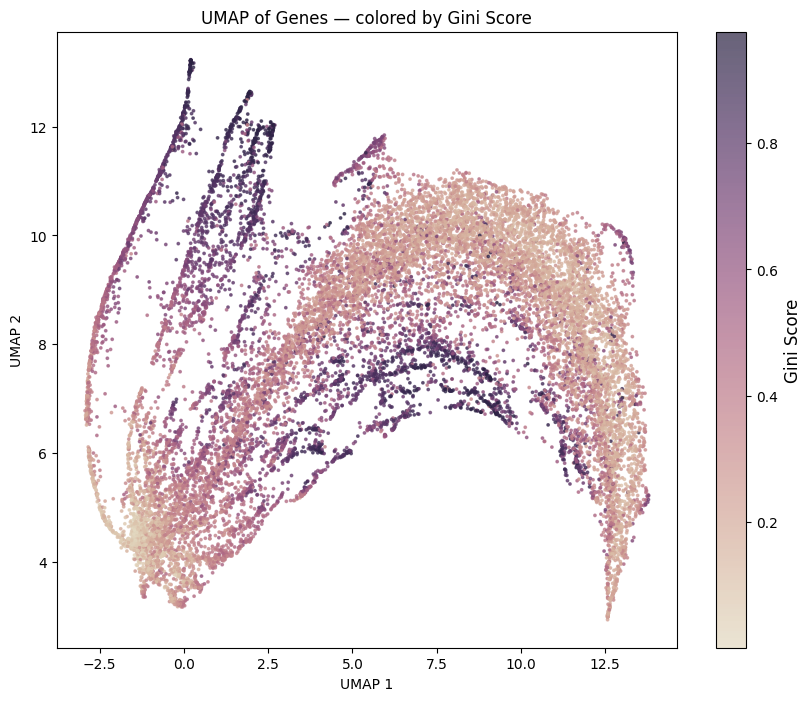

In [7]:
import umap
import matplotlib.cm as cm
import matplotlib.colors as mcolors


reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,    
    min_dist=0.1       
)
embedding = reducer.fit_transform(RNA_seq_val.values)

gini_scores = RNA_seq_gini["gini_score"].values
norm = mcolors.Normalize(vmin=gini_scores.min(), vmax=gini_scores.max())
cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True) 

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=gini_scores,          
    cmap=cmap,
    norm=norm,
    s=3,                    
    alpha=0.7,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Gini Score", fontsize=12)
cbar.ax.tick_params(labelsize=10)
ax.set_title("UMAP of Genes — colored by Gini Score")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.savefig('tilmann_plots/Umap of Genes - colored by Gini Score', dpi=300)
plt.show()

- genes with high gini score tend to cluster together
- connecting gini score to gene function is difficult (see next part)
    - could be the case be there are just immune cells available

### coloring the Umap with the categorizes, which were used in the gene variance scatter plot

In [56]:
import gseapy as gp

go_genesets = gp.get_library(name='GO_Biological_Process_2023', organism='Mouse')

gene2terms = {}
for term, genes in go_genesets.items():
    for gene in genes:
        gene2terms.setdefault(gene, set()).add(term)

category_keywords = {
    "housekeeping":  ["ribosom", "translation", "RNA processing",
                      "proteasome", "DNA repair", "cell cycle"],
    "immune":        ["immune", "T cell", "lymphocyte", "cytokine",
                      "interferon", "NF-kB", "antigen"],
    "metabolism":    ["metabolic", "biosynthesis", "oxidation",
                      "glycolysis", "lipid", "mitochondri"],
    "transcription": ["transcription", "chromatin", "histone", "epigenetic"],
    "signaling":     ["signaling", "kinase", "receptor", "MAPK", "PI3K"],
}

def assign_category(gene):
    terms = gene2terms.get(gene.upper(), set())   
    for category, keywords in category_keywords.items():
        for t in terms:                   
            for kw in keywords:           
                if kw.lower() in t.lower():
                    return category       
    return "other"   

In [57]:
RNA_seq_annot = RNA_seq.copy()

RNA_seq_annot["category"] = RNA_seq["Unnamed: 0"].apply(assign_category)
RNA_seq_annot.head()

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th,category
0,0610005C13Rik,1.096732,1.096732,1.021750,1.021812,1.205236,1.326780,1.392996,1.821243,1.025543,...,1.025785,1.251082,1.147249,1.024462,1.019656,1.017884,1.019107,1.017884,1.024720,other
1,0610007P14Rik,206.053987,246.105317,192.424636,204.298358,189.759175,210.195155,180.219440,137.802543,139.436719,...,105.140895,101.841463,175.620707,280.406964,200.228029,208.171821,88.578590,129.021874,140.655763,other
2,0610009B22Rik,78.272059,78.837030,68.844751,76.418169,106.085619,77.502817,68.213092,57.224426,56.787489,...,73.423656,68.881268,60.811907,56.578015,100.397766,37.373080,73.888468,77.191831,84.245816,other
3,0610009L18Rik,8.577159,16.791386,15.511549,16.947354,10.583704,8.664784,2.878172,8.952120,11.873984,...,8.965889,4.080445,11.987408,5.627219,4.227673,2.199352,1.460090,2.482516,1.023995,other
4,0610009O20Rik,168.645852,157.926022,155.941641,186.261464,162.584556,152.088002,163.072291,133.116083,88.052982,...,147.139323,130.924354,107.542142,88.338330,100.779150,86.442408,193.307175,187.212720,45.464889,other


In [58]:
color_map = {
    "housekeeping":  "#2196F370",  
    "immune":        "#F4433670",  
    "metabolism":    "#4CAF5070",  
    "transcription": "#FF980070",  
    "signaling":     "#9C27B070",  
    "other":         "#CCCCCC70",  
}

color_map_housekeeping = {  
    "housekeeping":  "#2196F3",  
    "immune":        "#F4433600",  
    "metabolism":    "#4CAF4F00",  
    "transcription": "#FF990000",  
    "signaling":     "#9B27B000",
    "other":         "#CCCCCC70",  
}

color_map_immune = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#F44336",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_metabolism = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#4CAF50",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_transcription = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#FF9800",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_signaling = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#9C27B0",  
    "other":         "#CCCCCC70",  
}

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


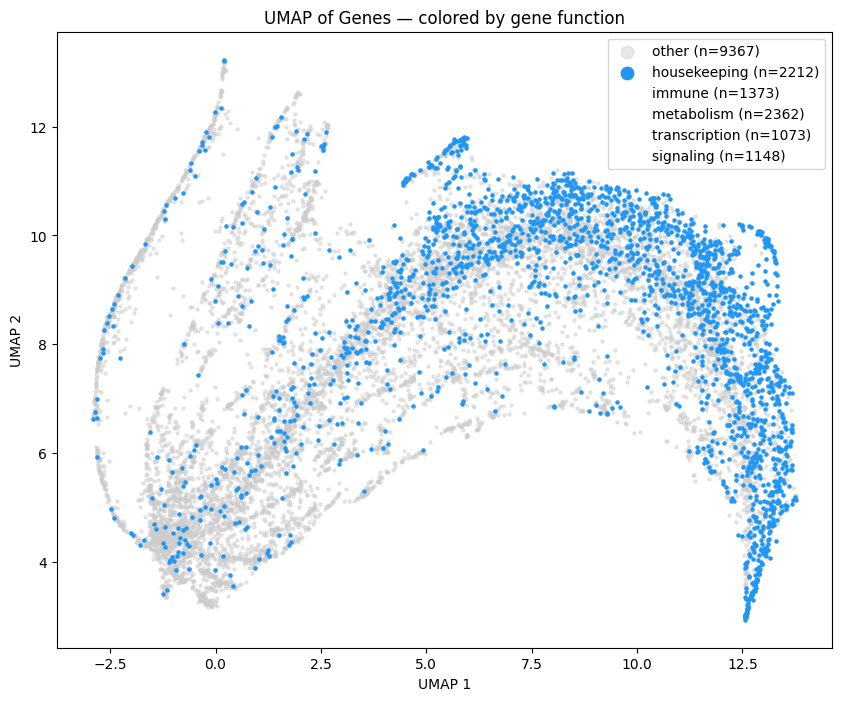

In [59]:
import umap

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,    
    min_dist=0.1       
)
embedding = reducer.fit_transform(RNA_seq_val.values)


fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    mask = RNA_seq_annot["category"] == category
    if not mask.any():
        continue

    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=color_map_housekeeping[category],
        label=f"{category} (n={mask.sum()})",
        s=5
    )


ax.set_title("UMAP of Genes — colored by gene function")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(markerscale=4, loc="upper right")
plt.savefig("tilmann_plots/UMAP of Genes - colored by gene function")
plt.show()

### clustering genes using hirachrical clustering (only genes with highest Gini score)

In [8]:
high_gini_genes = RNA_seq_gini[RNA_seq_gini["gini_score"] >= 0.80].copy()

In [9]:
high_gini_genes_val = high_gini_genes[high_gini_genes.columns[0:86]].copy()
high_gini_genes_val

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0610040J01Rik,4.307076,1.825867,1.137184,1.599585,21.654748,2.670317,2.231032,1.821243,1.025543,1.024819,...,79.895296,63.285812,18.201557,54.691322,3.450582,6.960233,1.207569,1.019107,1.017884,1.210441
1500009L16Rik,50.648485,58.681788,61.481768,37.877447,25.676097,29.131122,22.282160,1.025833,1.025543,1.024819,...,1.025785,1.025785,1.021812,2.442166,5.056484,15.549513,32.746569,3.221173,24.661872,13.774479
1600010M07Rik,1.096732,1.204281,1.021750,1.136401,1.634541,1.207683,1.024462,1.025833,15.877010,1.024819,...,22.622472,26.904262,299.305261,152.354252,7.612294,1.019656,3.510779,1.019107,1.017884,1.009448
1700071M16Rik,1.584588,1.021260,1.057774,1.107393,1.023171,1.021346,1.024462,1.025833,3.564250,1.024819,...,6.304838,10.055002,10.785852,2.604848,1.024462,1.019656,1.325557,1.135763,1.034742,1.005329
1810011H11Rik,17.244104,29.716559,41.474436,30.097395,12.379824,4.667017,1.692668,1.025833,1.025543,1.024819,...,120.163964,130.123320,85.425828,1.962105,3.872976,3.150296,1.207569,1.955324,1.505101,1.010659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp872,1.397914,1.021260,1.170825,1.708222,1.634541,1.186990,2.985519,2.259951,3.164873,1.024819,...,1.602130,1.625401,45.407324,387.169598,3.075937,1.344695,311.769540,1.235746,1.685365,236.958699
Zg16,1.625914,1.021260,1.021750,1.021812,1.023171,1.021346,1.024462,1.025833,1.025543,2.354292,...,1.025785,1.025785,1.021812,1.147249,1.024462,1.019656,1.017884,1.082738,20.854974,10.591534
Zmat4,1.211674,1.021260,1.057774,1.021812,1.023171,1.021346,1.392996,1.025833,2.134394,1.024819,...,1.602130,1.025785,2.466052,1.022767,1.024462,1.060366,1.041743,2.572223,1.202592,6.250735


In [10]:
high_gini_genes_val_z = high_gini_genes_val.sub(high_gini_genes_val.mean(axis=1), axis=0).div(high_gini_genes_val.std(axis=1), axis=0)
high_gini_genes_val_z = high_gini_genes_val_z.dropna(axis=0)
high_gini_genes_val_z.describe()

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
count,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,...,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000
mean,0.043601,-0.035295,-0.039342,-0.091862,-0.110343,-0.125015,-0.148953,-0.123232,-0.112681,-0.134966,...,0.252706,0.286206,0.095726,0.169872,-0.009726,1.443927,0.002096,1.122220,0.992277,1.250501
std,0.957481,0.725578,0.726653,0.579705,0.593376,0.546073,0.593395,0.623493,0.656153,0.491767,...,1.143385,1.248594,1.045564,1.329014,1.029780,2.951931,0.586592,2.627098,2.315396,2.776292
min,-0.505791,-0.507610,-0.505860,-0.505534,-0.518668,-0.511476,-0.508970,-0.516646,-0.501633,-0.516984,...,-0.504269,-0.496310,-0.508479,-0.508475,-0.488843,-0.515971,-0.483776,-0.516875,-0.516300,-0.496512
25%,-0.262686,-0.267574,-0.266716,-0.268201,-0.259052,-0.271448,-0.283141,-0.282353,-0.276109,-0.283668,...,-0.230767,-0.231044,-0.238577,-0.249524,-0.266350,-0.244736,-0.231042,-0.245488,-0.241491,-0.233616
50%,-0.181862,-0.186647,-0.186918,-0.189824,-0.191983,-0.197836,-0.202867,-0.203554,-0.199995,-0.204390,...,-0.157417,-0.157822,-0.169984,-0.178096,-0.190549,-0.124415,-0.144895,-0.130707,-0.123576,-0.111537
75%,-0.116815,-0.122161,-0.126533,-0.129405,-0.134373,-0.137604,-0.144020,-0.139631,-0.139276,-0.139695,...,-0.066917,-0.068402,-0.110032,-0.113454,-0.130058,1.622859,-0.023893,0.827317,1.013836,1.086222
max,8.097923,7.205902,6.528831,5.807867,7.196836,7.653856,8.991393,7.374652,9.146408,4.970203,...,5.934961,7.710240,9.147582,9.153421,9.063724,9.165763,7.589469,9.165571,9.165637,9.165786


/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


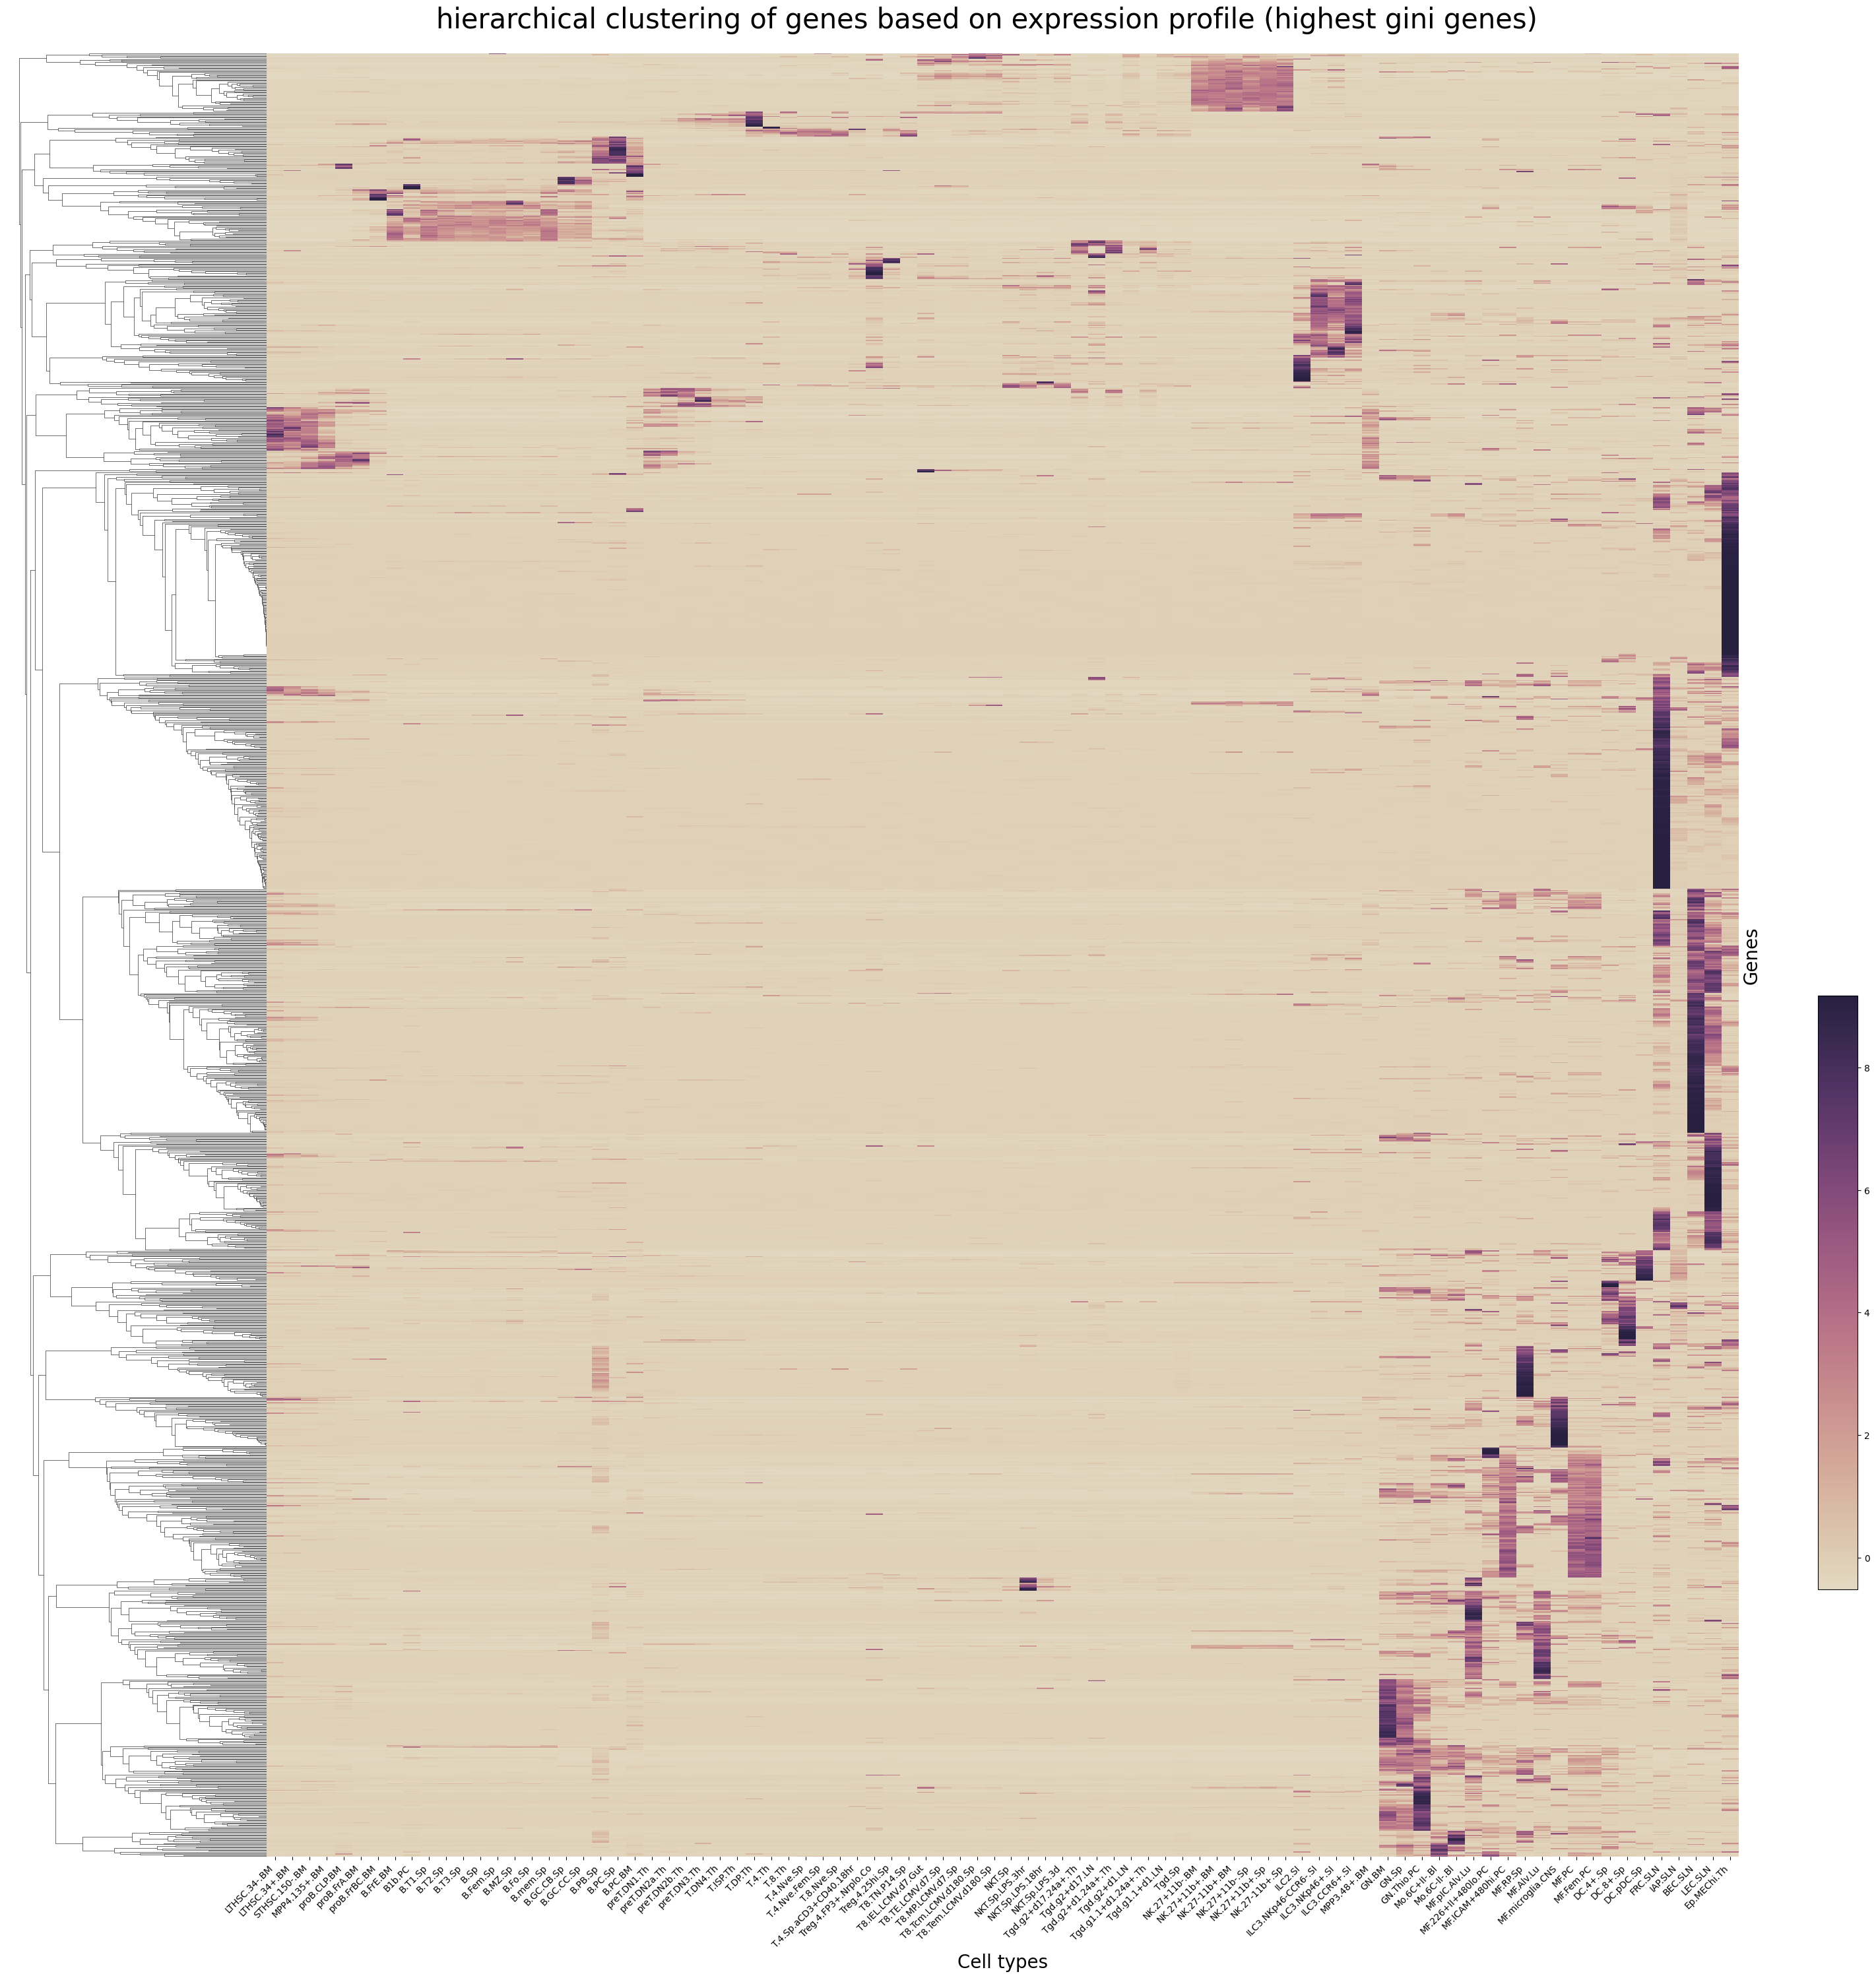

In [11]:
import seaborn as sns


vmin, vmax = high_gini_genes_val_z.min().min(), high_gini_genes_val_z.max().max()

g = sns.clustermap(
    high_gini_genes_val_z,                 
    row_cluster=True,
    col_cluster=False,
    method='average',
    metric='euclidean',
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    center=((vmin + vmax) / 2),
    vmin=vmin,
    vmax=vmax,           
    figsize=(30, 30),
    dendrogram_ratio=(0.15, 0.02),
    cbar_pos=None,
    yticklabels=False,
)

g.ax_heatmap.tick_params(axis='x', labelsize=10)
g.figure.subplots_adjust(right=0.88)
cax = g.figure.add_axes([0.92, 0.2, 0.02, 0.3])
plt.colorbar(g.ax_heatmap.collections[0], cax=cax)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_xlabel("Cell types", fontsize=20)
g.ax_heatmap.set_ylabel("Genes", fontsize=20)
g.figure.suptitle('hierarchical clustering of genes based on expression profile (highest gini genes)', y=1, fontsize=30)
plt.savefig('tilmann_plots/hierarchical clustering of genes based on expression profile (highest gini genes).png', dpi=300, bbox_inches='tight')
plt.savefig('plots_for_poster/hierarchical clustering of genes based on expression profile (highest gini genes).png', dpi=300, bbox_inches='tight')
plt.show()


 - many genes are mostly expressed in myeloid cell types
 - B-cells, stem-cells, and NK-cells have distinct sets of genes which are expressed throughout the groups
 - Treg-cells have a very specicfic set of genes not being expressed anywhere else
 - some genes seem to be destinct for a few Tgd-cells, but as clearly as for other cell types
 - it is not realy possible to identify shared genes between IL17 expressing cells

#### doing the same, but just with our cells

In [12]:
Tgd_cells = ["MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


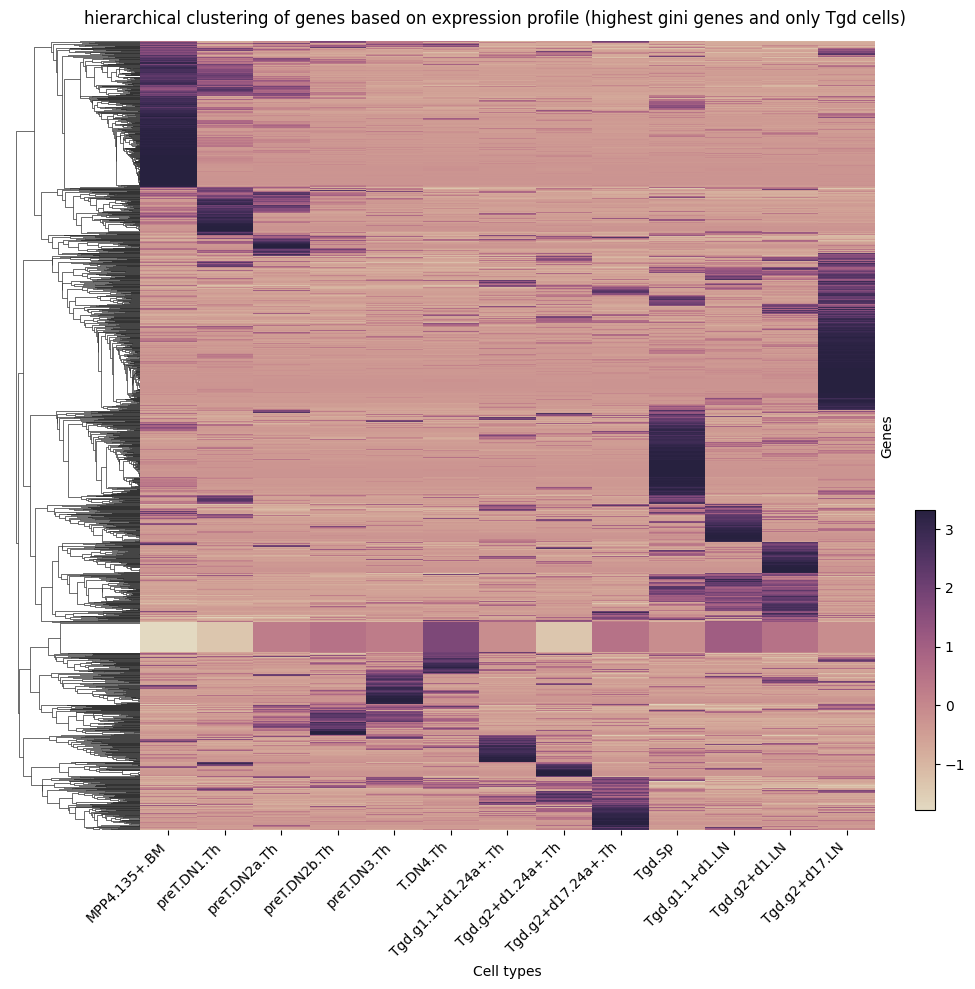

In [14]:
Tgd_high_gini = high_gini_genes_val[Tgd_cells].copy()

Tgd_high_gini_z = Tgd_high_gini.sub(Tgd_high_gini.mean(axis=1), axis=0).div(Tgd_high_gini.std(axis=1), axis=0)
Tgd_high_gini_z = Tgd_high_gini_z.dropna(axis=0)


vmin, vmax = Tgd_high_gini_z.min().min(), Tgd_high_gini_z.max().max()

g = sns.clustermap(
    Tgd_high_gini_z,                 
    row_cluster=True,
    col_cluster=False,
    method='average',
    metric='euclidean',
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    center=((vmin + vmax) / 2),
    vmin=vmin,
    vmax=vmax,           
    figsize=(10, 10),
    dendrogram_ratio=(0.15, 0.02),
    cbar_pos=None,
    yticklabels=False,
)

g.figure.subplots_adjust(right=0.88)
cax = g.figure.add_axes([0.92, 0.2, 0.02, 0.3])
plt.colorbar(g.ax_heatmap.collections[0], cax=cax)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_xlabel("Cell types")
g.ax_heatmap.set_ylabel("Genes")
g.figure.suptitle('hierarchical clustering of genes based on expression profile (highest gini genes and only Tgd cells)', y=1)
plt.savefig('tilmann_plots/hierarchical clustering of genes based on expression profile (highest gini genes and only Tgd cells).png', dpi=300, bbox_inches='tight')
plt.savefig('plots_for_poster/hierarchical clustering of genes based on expression profile (highest gini genes and only Tgd cells).png', dpi=300, bbox_inches='tight')
plt.show()

- the stem cells have a large distinst group of genes
- the is also a distinct cluster for the IL17 producing Tgd cells 
- in generall the overlap between cell types is not that visible (also due to the usage of high-gini-genes)
    - more overlap between the Tgd cells than with their progenitors
- gene cluster roughly represent cell lineage
    - the unique genes from the fully differentiated Tgd cell types are clustered together
    - genes from early progenitors are clustered together
    - genes from partially differentiated cells are clustered (both Tgd and Tab, even tough they are still quite seperate)

### hierachical clusterin of genes based on expression profiles (all genes)

In [ ]:
RNA_seq_z = RNA_seq_val.sub(RNA_seq_val.mean(axis=1), axis=0).div(RNA_seq_val.std(axis=1), axis=0)
RNA_seq_z = RNA_seq_z.dropna(axis=0)


vmin, vmax = RNA_seq_z.min().min(), RNA_seq_z.max().max()

g = sns.clustermap(
    RNA_seq_z,                 
    row_cluster=True,
    col_cluster=False,
    method='average',
    metric='euclidean',
    cmap="viridis",
    center=((vmin + vmax) / 2),
    vmin=vmin,
    vmax=vmax,           
    figsize=(30, 30),
    dendrogram_ratio=(0.15, 0.02),
    cbar_pos=None,
    yticklabels=False,
)

g.figure.subplots_adjust(right=0.88)
cax = g.figure.add_axes([0.92, 0.2, 0.02, 0.3])
plt.colorbar(g.ax_heatmap.collections[0], cax=cax)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_xlabel("Cell types")
g.ax_heatmap.set_ylabel("Genes")
g.figure.suptitle('hierarchical clustering of all genes based on expression profile', y=1, fontsize = 30)
plt.savefig('tilmann_plots/hierarchical clustering of all genes based on expression profile.png', dpi=300, bbox_inches='tight')
plt.show()

- no clear housekeeping genes or similar groups can be seen
- cell type specific gene cluster are better visible, when only the high-gini-genes are clustered

## Can you identify a lineage-specific gene set for your assigned cell type?

### identify specific genes using the Gini Score

In [49]:
Tgd_cells = ["MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

In [50]:
high_gini_genes = RNA_seq_gini[RNA_seq_gini["gini_score"] >= 0.80].copy()

top_gini_genes = RNA_seq_gini.nlargest(100, "gini_score").copy()

expr_only = high_gini_genes.drop(columns=["gini_score"])

high_gini_genes["dominant_cell_type"] = expr_only.idxmax(axis=1)

high_gini_genes["specificity_ratio"] = expr_only.max(axis=1) / expr_only.mean(axis=1)

marker_table = (
    high_gini_genes[["gini_score", "dominant_cell_type", "specificity_ratio"]]
    .sort_values(["dominant_cell_type", "gini_score"], ascending=[True, False])
)

In [51]:
gene_threshold = expr_only.mean(axis=1) + (1 * expr_only.std(axis=1)) 


marker_dict = {}

for cell_type in expr_only.columns:
    genes_above_threshold = expr_only.index[expr_only[cell_type] > gene_threshold].tolist()
    marker_dict[cell_type] = genes_above_threshold


max_len = max(len(g) for g in marker_dict.values())

specific_genes = pd.DataFrame({
    cell_type: genes + [""] * (max_len - len(genes))
    for cell_type, genes in marker_dict.items()
})

specific_genes

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,Adamtsl5,Adgrg1,9030619P08Rik,9030619P08Rik,9030619P08Rik,9030619P08Rik,Alpl,4930426D05Rik,Ackr2,4930426D05Rik,...,1810011O10Rik,1810011O10Rik,1600010M07Rik,1600010M07Rik,AI607873,A4galt,Acta2,1810011O10Rik,9430020K01Rik,1810011O10Rik
1,Adgrg1,Adgrl4,Adgrg1,Adgrg1,Adgrg3,Adgrg3,Bcat1,Bank1,Bank1,Bank1,...,4930455G09Rik,4930455G09Rik,AF251705,A530099J19Rik,Adam11,Abca8a,Adam11,6430548M08Rik,A4galt,2210407C18Rik
2,Adgrl4,Afap1l1,Adgrl4,Adgrg3,Bex6,Bex6,Bfsp2,Bcar3,Bhlhe41,Bcar3,...,6430548M08Rik,6430548M08Rik,AI607873,Acvrl1,Alox5ap,Abcc9,Adm,8430408G22Rik,AW551984,5330417C22Rik
3,Afap1l1,Ak1,Afap1l1,Adgrl4,Cd34,Bfsp2,Cecr2,Bfsp2,Blk,Bfsp2,...,Abca9,AI607873,Adam11,Adam11,Arhgef10l,Abhd3,Adrbk2,9430020K01Rik,Abca13,A4galt
4,Ak1,Aldh1a1,Angpt1,Afap1l1,Cox6a2,Camkv,Cplx2,Blk,Cacna1e,Blk,...,Abcd2,Abca9,Adam23,Adam23,Atp1a3,Abi3bp,Ankrd33b,A4galt,Ablim3,AA467197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,,,,,,,,,,,...,,,,,,Wdr86,,,,
475,,,,,,,,,,,...,,,,,,Wwtr1,,,,
476,,,,,,,,,,,...,,,,,,Yap1,,,,
477,,,,,,,,,,,...,,,,,,Zcchc14,,,,


#### what genes are specifically expressed in our cell types?

In [52]:
Tgd_RNA_seq_gini = RNA_seq_val[Tgd_cells].copy()
Tgd_RNA_seq_gini["gini_score"] = Tgd_RNA_seq_gini.apply(gini, axis=1)

Tgd_high_gini_genes = Tgd_RNA_seq_gini[Tgd_RNA_seq_gini["gini_score"] >= 0.80].copy()

Tgd_high_gini_genes

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN,gini_score
Unnamed: 0,,,,,,,,,,,,,,
9030619P08Rik,476.997814,373.221277,144.192162,20.725302,1.024482,1.026430,1.023995,1.022363,1.024819,1.023995,1.025543,1.024819,1.023995,0.803299
Abi3bp,1.107393,1.845686,1.389747,1.024819,1.024482,2.154155,1.719742,1.705768,1.024819,23.864604,2.960344,30.707140,740.353332,0.888486
Adgrl4,3804.040288,259.459841,24.322741,1.024819,1.024482,1.026430,1.023995,1.022363,1.024819,1.187178,1.025543,1.024819,1.023995,0.908609
Apol7c,1.021812,1.022363,1.024462,1.024819,1.024482,1.026430,1.023995,1.162753,1.024819,1.023995,1.025543,1.024819,104.697018,0.818004
Aqp3,1.136401,2.282939,1.024462,1.024819,1.024482,1.683173,8.543259,4.530512,14.637777,27.422363,49.339814,76.641800,691.649502,0.842826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tbxas1,240.216984,51.103672,70.471023,5.134996,1.024482,1.026430,1.023995,1.162753,1.024819,11.365100,2.030871,1.426854,1.023995,0.801994
Tie1,125.764178,2.503371,1.024462,1.024819,1.024482,1.026430,1.023995,1.022363,1.024819,1.023995,1.708549,1.516044,1.236400,0.830220
Vcam1,48.176054,3.474019,3.534545,1.024819,1.024482,1.026430,1.023995,1.022363,1.024819,280.995787,1.721247,1.426854,7.418707,0.851988


In [53]:
Tgd_expr_only = expr_only[Tgd_cells].copy()

In [54]:
Tgd_gene_threshold = Tgd_expr_only.mean(axis=1) + (1.96 * Tgd_expr_only.std(axis=1)) 


Tgd_marker_dict = {}

for cell_type in Tgd_expr_only.columns:
    Tgd_genes_above_threshold = Tgd_expr_only.index[Tgd_expr_only[cell_type] > Tgd_gene_threshold].tolist()
    Tgd_marker_dict[cell_type] = Tgd_genes_above_threshold


max_len = max(len(g) for g in Tgd_marker_dict.values())

Tgd_specific_genes = pd.DataFrame({
    cell_type: genes + [""] * (max_len - len(genes))
    for cell_type, genes in Tgd_marker_dict.items()
})

Tgd_specific_genes

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,1810011H11Rik,1600010M07Rik,5330417C22Rik,1500009L16Rik,AA467197,Antxr1,9830107B12Rik,Actn3,5830411N06Rik,1810011O10Rik,AI839979,0610040J01Rik,1700071M16Rik
1,4933431E20Rik,8430408G22Rik,Aatk,Adamts9,Acod1,Apol11b,Astn1,Bmp8a,Ackr4,4930455G09Rik,Abhd3,2010300C02Rik,2210407C18Rik
2,9030619P08Rik,Aatk,Adam33,Aire,Alpl,Apold1,Bcar1,C5ar1,Acta2,6430548M08Rik,Adamts1,AI839979,A530099J19Rik
3,9830166K06Rik,Abcc8,Adamts9,Alox15,Amer2,Aqp7,Cd4,Cacna1i,Angptl2,A530064D06Rik,Adh1,Abcc9,AW551984
4,A4galt,Adam11,Aicda,Ankrd22,Aoc1,Arhgef15,Chil3,Ccr8,Ano1,AF251705,Akr1c14,Ache,Abca8a
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Wfdc18,,,,,,,,,,,,Xcr1
284,Zfp521,,,,,,,,,,,,Zbtb16
285,,,,,,,,,,,,,Zfp872
286,,,,,,,,,,,,,Zmat4


- These lists of genes should roughly represent the clusters from the heatmap
- number of specific genes tends to decrease as the cells get more differentiated
- IL17 is not listed, because it is expressed in multiple cell types and does not have a high Gini score

#### coloring the Umap scatter plot with the specific genes for Tgd cells

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


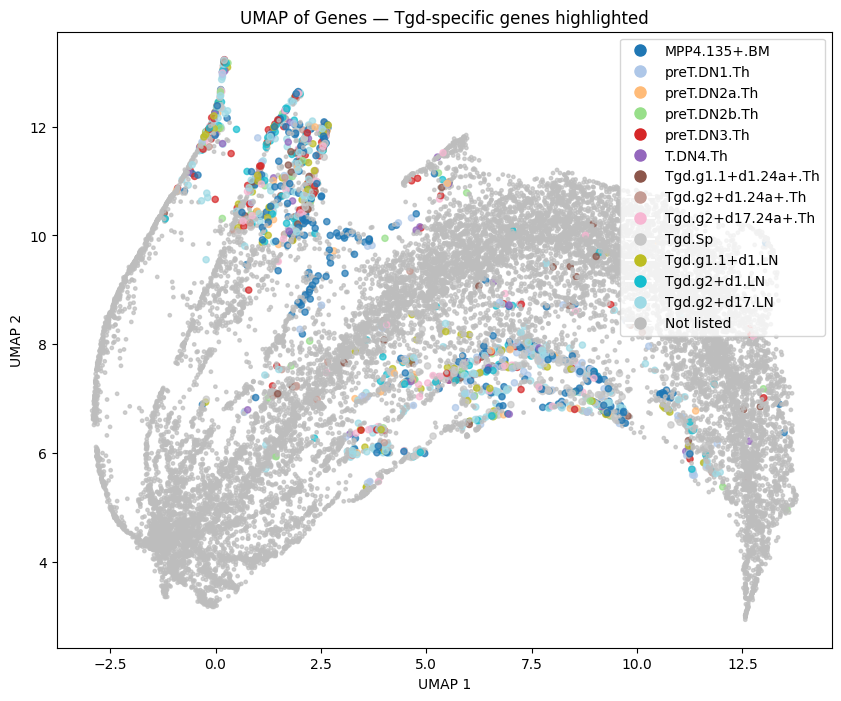

In [55]:
# coloring was done with Claude Sonnet 4.6

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,
    min_dist=0.1
)
embedding = reducer.fit_transform(RNA_seq_val.values)

column_colors = {
    col: color
    for col, color in zip(
        Tgd_specific_genes.columns,
        plt.cm.tab20(np.linspace(0, 1, len(Tgd_specific_genes.columns)))
    )
}

point_colors = []
point_sizes = []
for gene in RNA_seq_gini.index:
    matching_columns = [
        col for col in Tgd_specific_genes.columns
        if str(gene) in Tgd_specific_genes[col].dropna().astype(str).tolist()
    ]
    if matching_columns:
        point_colors.append(column_colors[matching_columns[0]])
        point_sizes.append(20)
    else:
        point_colors.append("#bdbdbd")
        point_sizes.append(6)

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=point_colors,
    s=point_sizes,
    alpha=0.7,
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker='o', color='w', label=col,
        markerfacecolor=column_colors[col], markeredgecolor=column_colors[col], markersize=8
    )
    for col in Tgd_specific_genes.columns
]
legend_handles.append(
    plt.Line2D([0], [0], marker='o', color='w', label='Not listed',
              markerfacecolor='#bdbdbd', markeredgecolor='#bdbdbd', markersize=8)
)
ax.legend(handles=legend_handles, loc='upper right')

ax.set_title("UMAP of Genes — Tgd-specific genes highlighted")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.savefig('tilmann_plots/Umap of Genes - highlighted specific genes for Tgd cells', dpi=300)
plt.show()

- no groups of genes associated with a certain cell type can be seen

### calculating the mean expression of genes across cell groups and then calculating Gini score to identify group-specific genes

In [60]:
cells_groups = pd.read_csv('data/cells_groups.csv')
cells_groups.loc[cells_groups["Act_T"] == "T8.IEL.LCMV.d7.SI", "Act_T"] = np.nan
cells_groups.loc[cells_groups["B_cells"] == "preB.FrD.BM", "B_cells"] = np.nan
cells_groups.loc[cells_groups["MF/GN"] == "MF.LP.SI", "MF/GN"] = np.nan
cells_groups.loc[cells_groups["DC"] == "DC.103+11b+.SI", "DC"] = np.nan
cells_groups.loc[cells_groups["DC"] == "DC.103+11b-.SI"] = np.nan
cells_groups

,gdT,abT,Act_T,B_cells,Stem,ILC,MF/GN,Mo,DC,Stroma
0,Tgd.g2+d17.24a+.Th,preT.DN1.Th,T.4.Sp.aCD3+CD40.18hr,proB.CLP.BM,LTHSC.34-.BM,NK.27+11b-.BM,GN.BM,Mo.6C+II-.Bl,DC.4+.Sp,FRC.SLN
1,Tgd.g2+d17.LN,preT.DN2a.Th,T8.TN.P14.Sp,proB.FrA.BM,LTHSC.34+.BM,NK.27+11b+.BM,GN.Sp,Mo.6C-II-.Bl,DC.8+.Sp,IAP.SLN
2,Tgd.g2+d1.24a+.Th,preT.DN2b.Th,NaN,proB.FrBC.BM,STHSC.150-.BM,NK.27-11b+.BM,GN.Thio.PC,NaN,DC.pDC.Sp,BEC.SLN
3,Tgd.g2+d1.LN,preT.DN3.Th,T8.TE.LCMV.d7.Sp,NaN,MPP4.135+.BM,NK.27+11b-.Sp,MF.pIC.Alv.Lu,NaN,NaN,LEC.SLN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Tgd.g1.1+d1.LN,T.ISP.Th,T8.Tcm.LCMV.d180.Sp,B1b.PC,NaN,NK.27-11b+.Sp,MF.ICAM+480hi.PC,NaN,NaN,NaN
6,Tgd.Sp,T.DP.Th,T8.Tem.LCMV.d180.Sp,B.T1.Sp,NaN,ILC2.SI,MF.RP.Sp,NaN,NaN,NaN
7,NaN,T.4.Th,NKT.Sp.LPS.3hr,B.T2.Sp,NaN,ILC3.NKp46-CCR6-.SI,NaN,NaN,NaN,NaN
8,NaN,T.8.Th,NKT.Sp.LPS.18hr,B.T3.Sp,NaN,ILC3.NKp46+.SI,MF.Alv.Lu,NaN,NaN,NaN
9,NaN,T.4.Nve.Sp,NKT.Sp.LPS.3d,B.Sp,NaN,ILC3.CCR6+.SI,MF.microglia.CNS,NaN,NaN,NaN


In [61]:
RNA_seq_group_val = pd.DataFrame({
    "gdT": RNA_seq_val[cells_groups["gdT"].dropna()].mean(axis=1),
    "abT": RNA_seq_val[cells_groups["abT"].dropna()].mean(axis=1),
    "Act_T": RNA_seq_val[cells_groups["Act_T"].dropna()].mean(axis=1),
    "B_cells": RNA_seq_val[cells_groups["B_cells"].dropna()].mean(axis=1),
    "Stem": RNA_seq_val[cells_groups["Stem"].dropna()].mean(axis=1),
    "ILC": RNA_seq_val[cells_groups["ILC"].dropna()].mean(axis=1),
    "MF/GN": RNA_seq_val[cells_groups["MF/GN"].dropna()].mean(axis=1),
    "Mo": RNA_seq_val[cells_groups["Mo"].dropna()].mean(axis=1),
    "DC": RNA_seq_val[cells_groups["DC"].dropna()].mean(axis=1),
    "Stroma": RNA_seq_val[cells_groups["Stroma"].dropna()].mean(axis=1),
})
RNA_seq_group_val

,gdT,abT,Act_T,B_cells,Stem,ILC,MF/GN,Mo,DC,Stroma
Unnamed: 0,,,,,,,,,,
0610005C13Rik,1.048455,1.340156,1.094539,1.409515,1.059256,2.019415,1.165284,1.366272,1.140931,1.018633
0610007P14Rik,129.273295,166.698279,197.759296,177.443925,212.220574,137.239544,85.113723,110.030251,185.956378,156.500079
0610009B22Rik,36.712883,44.949608,41.115424,54.110361,75.593002,32.647340,77.615445,67.496727,62.090397,72.212786
0610009L18Rik,12.821176,10.739169,9.637014,11.656444,14.456862,12.282199,14.699289,6.247425,7.231690,2.592407
0610009O20Rik,95.429227,111.761370,96.214018,110.599546,167.193745,113.371776,108.517178,66.417659,108.934942,141.935363
...,...,...,...,...,...,...,...,...,...,...
Zyx,1229.500192,498.409045,1024.565140,219.639569,1234.988345,1674.869624,1290.880979,1775.267209,784.671236,407.529216
Zzef1,307.434952,281.524215,318.147140,291.290007,157.697602,394.752992,266.528648,357.243302,311.974752,212.473982
Zzz3,282.832416,306.927736,264.213018,242.183587,303.831228,232.409778,198.995320,185.055535,228.695046,228.683095


In [62]:
RNA_seq_group_gini = RNA_seq_group_val.copy()
RNA_seq_group_gini["gini_score"] = RNA_seq_group_gini.apply(gini, axis=1)

In [63]:
high_gini_group_genes = RNA_seq_group_gini[RNA_seq_group_gini["gini_score"] >= 0.80].copy()

expr_only_group = high_gini_group_genes.drop(columns=["gini_score"])

high_gini_group_genes["dominant_cell_type"] = expr_only_group.idxmax(axis=1)

high_gini_group_genes["specificity_ratio"] = expr_only_group.max(axis=1) / expr_only_group.mean(axis=1)

In [64]:
gene_threshold_group = expr_only_group.mean(axis=1) 


marker_dict_group = {}

for cell_type in expr_only_group.columns:
    genes_above_threshold_group = expr_only_group.index[expr_only_group[cell_type] > gene_threshold_group].tolist()
    marker_dict_group[cell_type] = genes_above_threshold_group


max_len = max(len(g) for g in marker_dict_group.values())

specific_genes_group = pd.DataFrame({
    cell_type: genes + [""] * (max_len - len(genes))
    for cell_type, genes in marker_dict_group.items()
})

specific_genes_group

,gdT,abT,Act_T,B_cells,Stem,ILC,MF/GN,Mo,DC,Stroma
0,5830411N06Rik,Arpp21,Acod1,Aicda,Adgrg1,Adamts14,1810011O10Rik,Ace,A530099J19Rik,1810011O10Rik
1,Arpp21,Foxp3,Eomes,C6,Adgrl4,Adamts15,9830107B12Rik,Adgre4,Adam11,9430020K01Rik
2,Cd163l1,Il10,Gzma,Cd19,Angpt1,Arg1,Acod1,Alox5,Adam23,A4galt
3,Eomes,Mycn,Gzmk,Cd79a,Car2,Bmp2,Acta2,Arhgef37,Apol7c,AW551984
4,Gzma,Nwd1,Ifng,Chst3,Casp12,Bmp4,Adgre4,C5ar1,Asprv1,Abca8a
...,...,...,...,...,...,...,...,...,...,...
395,,,,,,,,,,Vtn
396,,,,,,,,,,Vwa1
397,,,,,,,,,,Wwtr1
398,,,,,,,,,,Yap1


#### coloring the Umap scatter plot with the group-specific genes

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


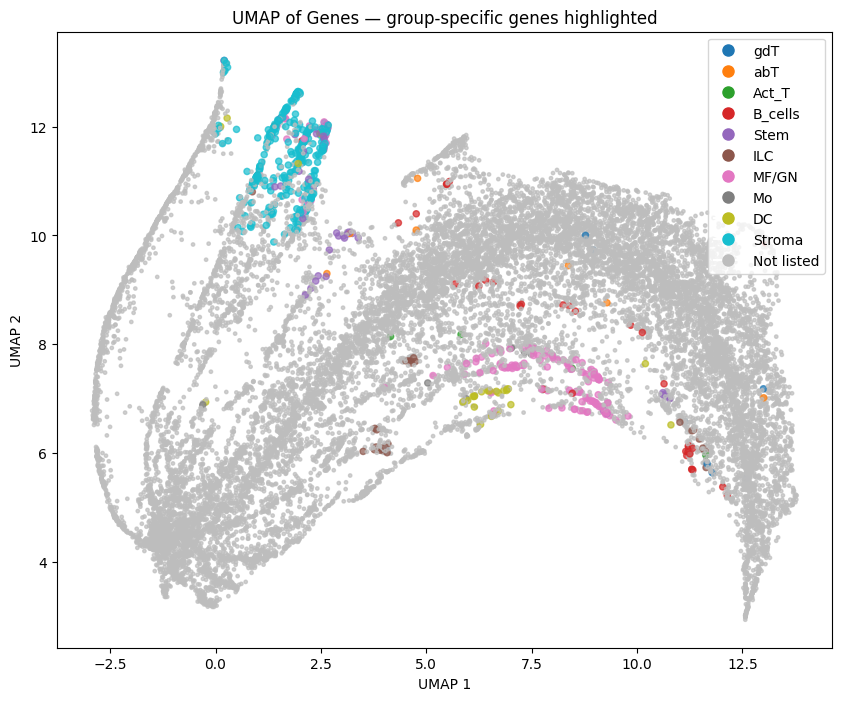

In [66]:
# coloring was done with Claude Sonnet 4.6

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,
    min_dist=0.1
)
embedding = reducer.fit_transform(RNA_seq_val.values)

column_colors = {
    col: color
    for col, color in zip(
        specific_genes_group.columns,
        plt.cm.tab10(np.linspace(0, 1, len(specific_genes_group.columns)))
    )
}

point_colors = []
point_sizes = []
for gene in RNA_seq_group_gini.index:
    matching_columns = [
        col for col in specific_genes_group.columns
        if str(gene) in specific_genes_group[col].dropna().astype(str).tolist()
    ]
    if matching_columns:
        point_colors.append(column_colors[matching_columns[0]])
        point_sizes.append(20)
    else:
        point_colors.append("#bdbdbd")
        point_sizes.append(6)

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=point_colors,
    s=point_sizes,
    alpha=0.7,
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker='o', color='w', label=col,
        markerfacecolor=column_colors[col], markeredgecolor=column_colors[col], markersize=8
    )
    for col in specific_genes_group.columns
]
legend_handles.append(
    plt.Line2D([0], [0], marker='o', color='w', label='Not listed',
              markerfacecolor='#bdbdbd', markeredgecolor='#bdbdbd', markersize=8)
)
ax.legend(handles=legend_handles, loc='upper right')

ax.set_title("UMAP of Genes — group-specific genes highlighted")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.savefig('tilmann_plots/Umap of Genes - highlighted specific genes by column', dpi=300)
plt.savefig('plots_for_poster/Umap of Genes - highlighted specific genes by column', dpi=300)
plt.show()

- some groups are visible, but there is no clear seperation
- it again shows which regions in this scatter plot contain more genes with a high Gini score

## Are there subclusters of particular biological interest? (we fokus on IL17 in the next part)

# Looking at the IL17 locus in different cell types 

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [16]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq = pd.read_csv('data/mmc2.csv')

RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_seq_val = RNA_seq.drop(columns="Unnamed: 0").copy()
RNA_seq_val.index = RNA_seq["Unnamed: 0"]

## loading the IL17 data sets

In [17]:
RNA_seq_IL17 = pd.read_csv('data/RNA_seq_IL17.csv')

RNA_seq_IL17_val = RNA_seq_IL17.drop(columns="Unnamed: 0").copy()
RNA_seq_IL17_val.index = RNA_seq_IL17["Unnamed: 0"]

RNA_seq_IL17_val


,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Il17a,1.020795,1.02126,1.021750,1.021812,1.023171,1.140409,1.024462,1.025833,1.025543,1.024819,...,1.025785,1.025785,1.021812,1.022767,1.024462,1.019656,1.017884,1.019107,1.017884,1.005329
Il17b,1.020795,1.02126,1.021750,1.021812,1.023171,1.021346,1.024462,1.025833,1.025543,1.024819,...,1.025785,1.025785,1.126600,1.022767,1.024462,1.019656,1.017884,1.040295,1.017884,1.052731
Il17c,1.020795,1.02126,1.021750,1.021812,1.368419,1.021346,1.024462,3.296594,1.516769,3.383058,...,1.025785,1.634780,1.146294,1.147249,1.685787,1.019656,1.017884,1.443479,1.017884,1.041095
Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,1.024819,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.135090,1.017884,1.040295,1.017884,1.021351


table to compare IL17 expression in different cell types

In [18]:
cells_to_compare = ["Tgd.g2+d17.LN", "Tgd.g2+d1.LN", "ILC3.CCR6+.SI", "NKT.Sp.LPS.3hr", "T.4.Th"]

IL17_expression_comparison = RNA_seq_IL17_val[cells_to_compare].copy()
IL17_expression_comparison.to_csv('data/IL17_expression_comparison_for_poster.csv', index=True, header=True)
IL17_expression_comparison

,Tgd.g2+d17.LN,Tgd.g2+d1.LN,ILC3.CCR6+.SI,NKT.Sp.LPS.3hr,T.4.Th
Unnamed: 0,,,,,
Il17a,1.023995,1.024819,104.836685,34.636492,1.024462
Il17b,1.023995,1.024819,1.023171,1.025833,1.024462
Il17c,1.023995,1.426854,1.023171,1.025833,1.024462
Il17f,40.083782,3.957685,267.749944,24.580994,1.024462


In [19]:
ATAC_seq_IL17 = pd.read_csv('data/ATAC_seq_IL17.csv')

### were is IL17 expressed?

In [20]:
mean_IL17_expr = RNA_seq_IL17_val.to_numpy().mean()
std_IL17_expr = RNA_seq_IL17_val.to_numpy().std()

IL17_expr_cells_RNA = RNA_seq_IL17_val[RNA_seq_IL17_val.columns[RNA_seq_IL17_val.max(axis=0) > 10]].copy()
IL17_expr_cells_RNA
                

,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI
Unnamed: 0,,,,,,
Il17a,1.025785,23.987840,34.636492,1.023995,42.175516,104.836685
Il17b,1.025785,1.024859,1.025833,1.023995,1.022363,1.023171
Il17c,1.565833,1.206231,1.025833,1.023995,1.271327,1.023171
Il17f,10.462818,1.024859,24.580994,40.083782,75.919477,267.749944


In [21]:
IL17_expr_cells_ATAC = ATAC_seq_IL17[RNA_seq_IL17_val.columns[RNA_seq_IL17_val.max(axis=0) > 10]].copy()
IL17_expr_cells_ATAC[ATAC_seq_IL17.columns[0:8]] = ATAC_seq_IL17[ATAC_seq_IL17.columns[0:8]]
IL17_expr_cells_ATAC["Tgd.g2+d1.LN"] = ATAC_seq_IL17["Tgd.g2+d1.LN"] #as a reference

## IL17f

### plotting OCRs near the IL17f gene locus

In [22]:
gene_annotations = pd.read_csv('data/gene_annotations.csv')
IL17_genes = gene_annotations[gene_annotations['gene_name'].str.contains('Il17a|Il17b|Il17c|Il17d|Il17f', case=False, na=False)].copy()
IL17_genes

,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
2079,Il17a,NM_010552,chr1,+,20730904,20734496,20730961,20733859,3,"20730904,20732095,20733621,","20730988,20732307,20734496,"
4195,Il17b,NM_019508,chr18,+,61687934,61692537,61687983,61692437,3,"61687934,61690117,61692205,","61688004,61690407,61692537,"
8932,Il17f,NM_145856,chr1,-,20777145,20784270,20777766,20784199,3,"20777145,20779290,20784172,","20778004,20779511,20784270,"
34980,Il17c,NM_145834,chr8,+,122422019,122423639,122422118,122423568,2,"122422019,122423306,","122422405,122423639,"
36895,Il17d,NM_145837,chr14,+,57524828,57543166,57524906,57542640,3,"57524828,57525303,57542333,","57524921,57525599,57543166,"


In [23]:
IL17f_start = IL17_genes.loc[8932, "txEnd"]
IL17f_end = IL17_genes.loc[8932, "txStart"]

In [24]:
ATAC_seq_IL17f = IL17_expr_cells_ATAC[IL17_expr_cells_ATAC['genes.within.100Kb'].str.contains('Il17f', case=False, na=False)].copy()
ATAC_seq_IL17f

,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,Tgd.g2+d1.LN
1,2.14,1.89,5.04,56.70,26.18,32.45,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",4.17
2,2.76,2.73,2.87,4.15,2.09,6.65,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",1.95
3,1.12,1.89,1.09,2.60,0.57,0.15,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.68
4,1.16,2.11,4.08,26.14,19.37,17.47,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.91
5,2.76,3.01,2.12,13.28,11.12,16.75,ImmGenATAC1219.peak_2083,chr1,20738699,0.19,3.41,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.95
6,8.52,7.02,4.96,25.00,35.01,42.39,ImmGenATAC1219.peak_2084,chr1,20740472,0.00,13.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",6.71
7,12.49,9.83,8.79,71.34,67.30,58.74,ImmGenATAC1219.peak_2085,chr1,20740740,0.34,24.17,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",18.62
8,2.02,17.36,0.95,69.89,2.65,0.15,ImmGenATAC1219.peak_2086,chr1,20744070,0.00,7.53,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",5.03
9,0.38,1.99,1.14,0.13,0.95,1.41,ImmGenATAC1219.peak_2087,chr1,20748728,0.45,2.59,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.12
10,2.29,6.33,11.87,44.26,32.10,28.01,ImmGenATAC1219.peak_2089,chr1,20754593,0.29,8.58,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.95


In [25]:
IL17f_data = ATAC_seq_IL17f.iloc[:, 0:6].copy()
IL17f_data["Summit"] = ATAC_seq_IL17f["Summit"]
IL17f_data.insert(0, "Tgd.g2+d1.LN", ATAC_seq_IL17f["Tgd.g2+d1.LN"])
IL17f_data

,Tgd.g2+d1.LN,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI,Summit
1,4.17,2.14,1.89,5.04,56.70,26.18,32.45,20686124
2,1.95,2.76,2.73,2.87,4.15,2.09,6.65,20700177
3,0.68,1.12,1.89,1.09,2.60,0.57,0.15,20701584
4,1.91,1.16,2.11,4.08,26.14,19.37,17.47,20725819
5,1.95,2.76,3.01,2.12,13.28,11.12,16.75,20738699
6,6.71,8.52,7.02,4.96,25.00,35.01,42.39,20740472
7,18.62,12.49,9.83,8.79,71.34,67.30,58.74,20740740
8,5.03,2.02,17.36,0.95,69.89,2.65,0.15,20744070
9,0.12,0.38,1.99,1.14,0.13,0.95,1.41,20748728
10,1.95,2.29,6.33,11.87,44.26,32.10,28.01,20754593


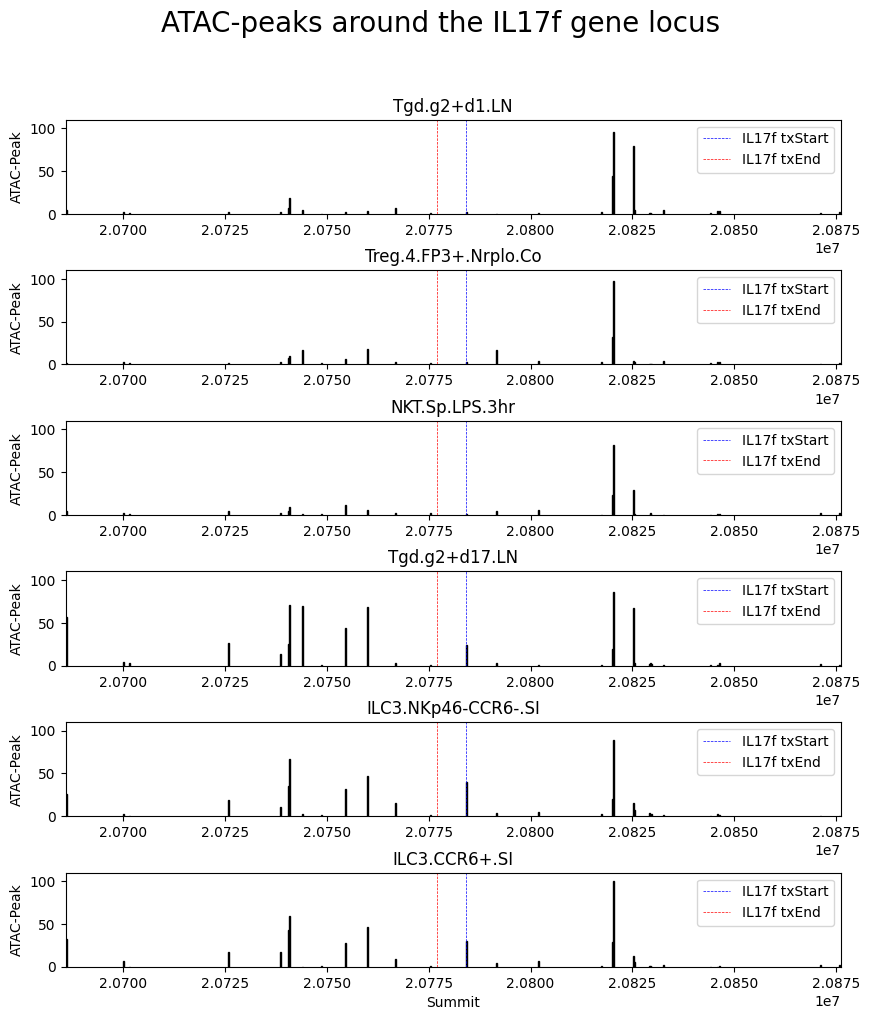

In [48]:
summits = "Summit"
cell_types = ["Tgd.g2+d1.LN",
            "Treg.4.FP3+.Nrplo.Co",
            "NKT.Sp.LPS.3hr",
            "Tgd.g2+d17.LN",
            "ILC3.NKp46-CCR6-.SI",
            "ILC3.CCR6+.SI",
]


fig, axs = plt.subplots(6, 1, figsize=(10, 11), sharex=False, gridspec_kw={"hspace": 0.6})


IL17f_data = IL17f_data.sort_values(summits)

x = IL17f_data[summits].to_list()


for ax, cell_type, t in zip(axs, cell_types, cell_types):
    y = IL17f_data[cell_type].to_list()

    ax.bar(x, y, width=250, color="black", edgecolor="black")
    ax.set_title(t)
    ax.set_ylabel("ATAC-Peak")
    ax.axvline(IL17f_start, color='blue', linestyle='--', linewidth=0.5, label='IL17f txStart')
    ax.axvline(IL17f_end, color='red', linestyle='--', linewidth=0.5, label='IL17f txEnd')
    ax.legend()
    ax.set_ylim(0, 110)
    ax.set_xlim(min(x) - 250, max(x) + 250)

axs[-1].set_xlabel("Summit")

fig.suptitle("ATAC-peaks around the IL17f gene locus", fontsize=20)
plt.savefig('tilmann_plots/ATAC-peaks around the IL17f gene locus', dpi=300)
plt.savefig('plots_for_poster/ATAC-peaks around the IL17f gene locus', dpi=300)
plt.show()


- the clearest difference between those cell types, which express IL17f and those, which do not, is the OCR at the TSS
- one OCR upstream is active everywhere
- another OCR upstream is especially active in both Tgd cell types
- in IL17f expressing cells there seem to be more active OCRs downstream from the gene
- the OCR-pattern of NK.Sp.LPS.3hr looks similar to those cells not expressing IL17f, even though they do express some IL17f (expression value: 25)
- peak at 2744000 is unique to Tgd.g2+d17.LN

Data from UCSC Genome Browser on Mouse as a comparison

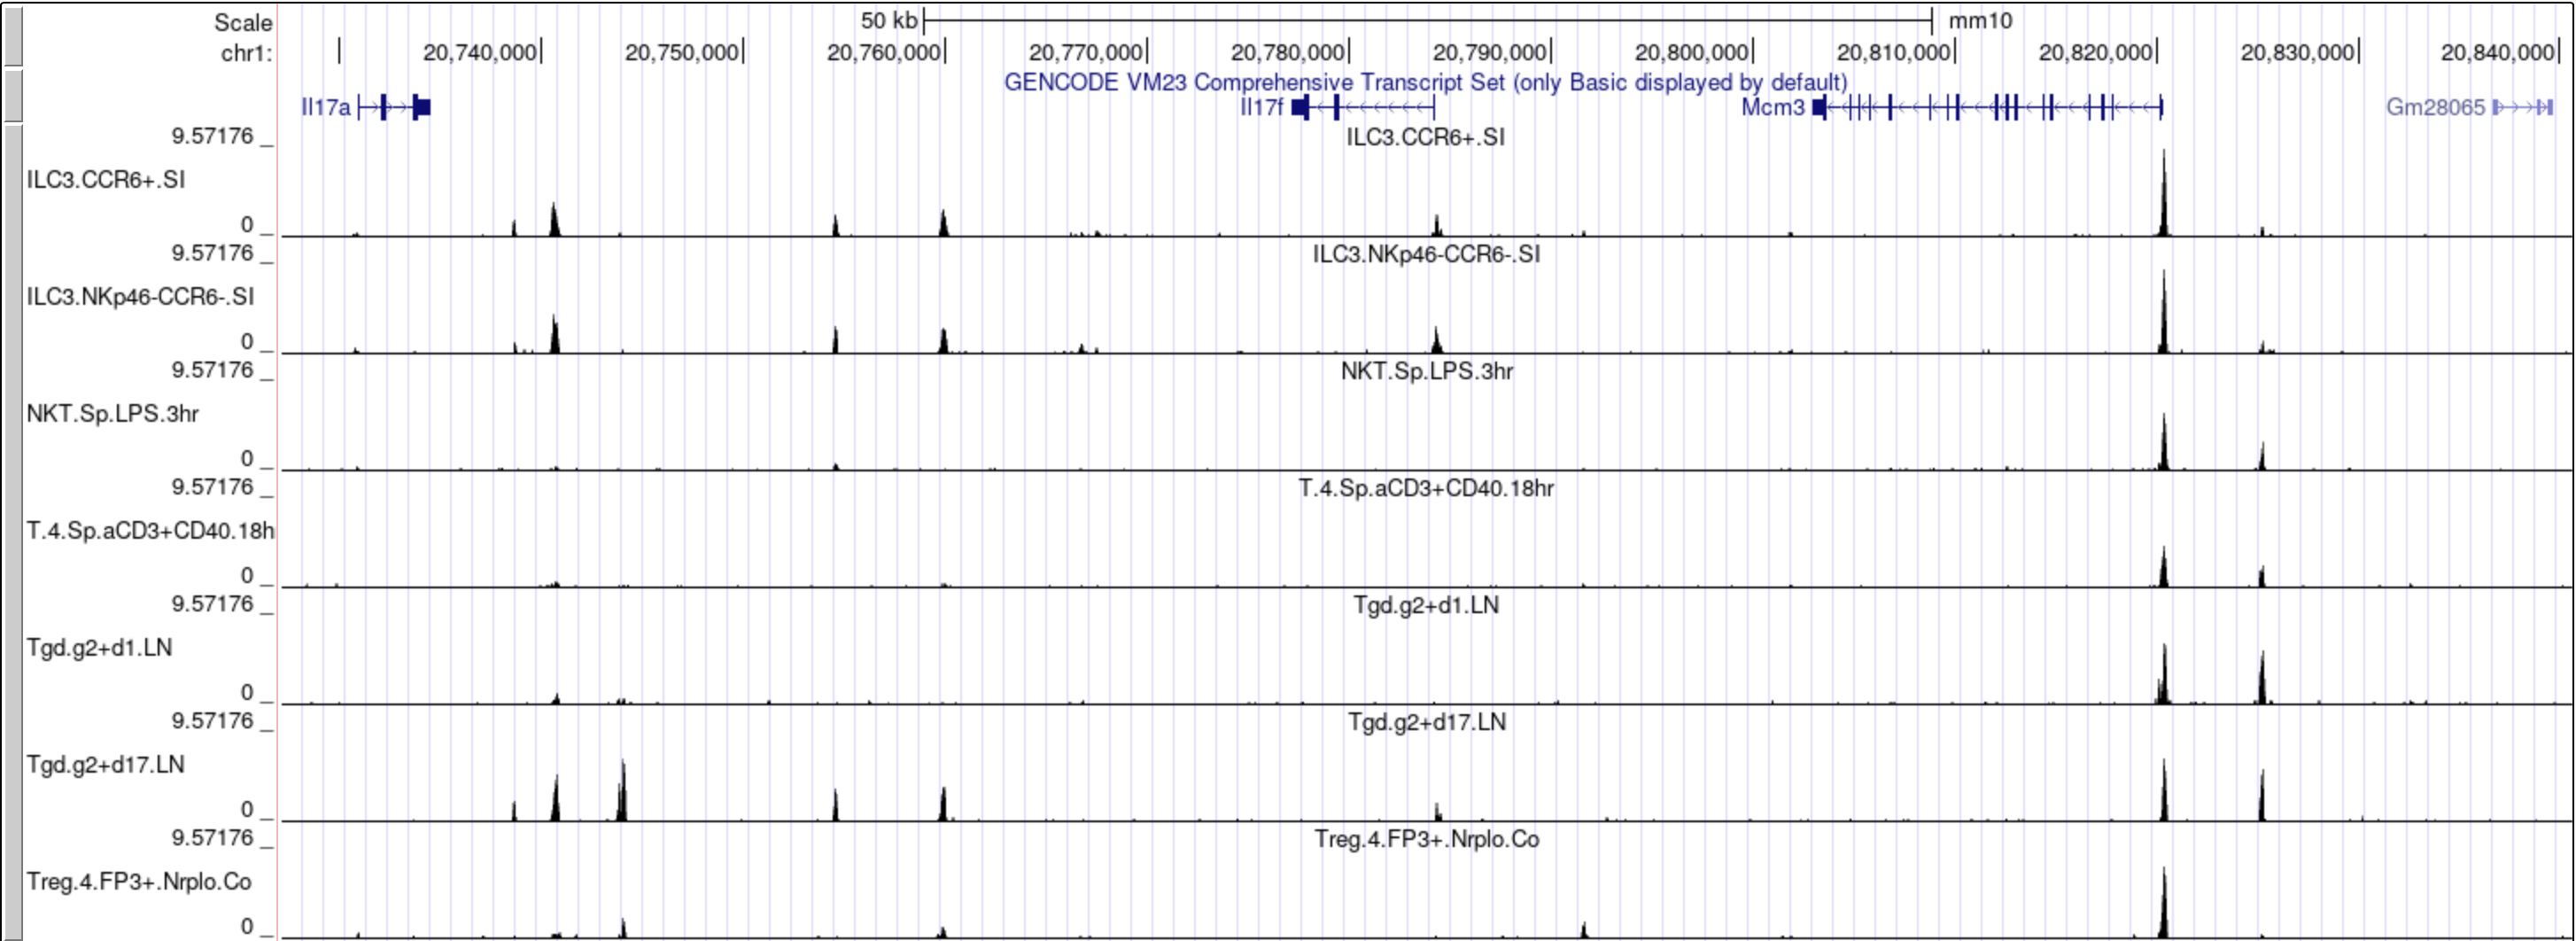

some potential transcription factor for the unique peak from JASPAR (UCSC Genome Browser on Mouse)
- some of these transcription factors are also expressed in IL17 producing Tgd cells

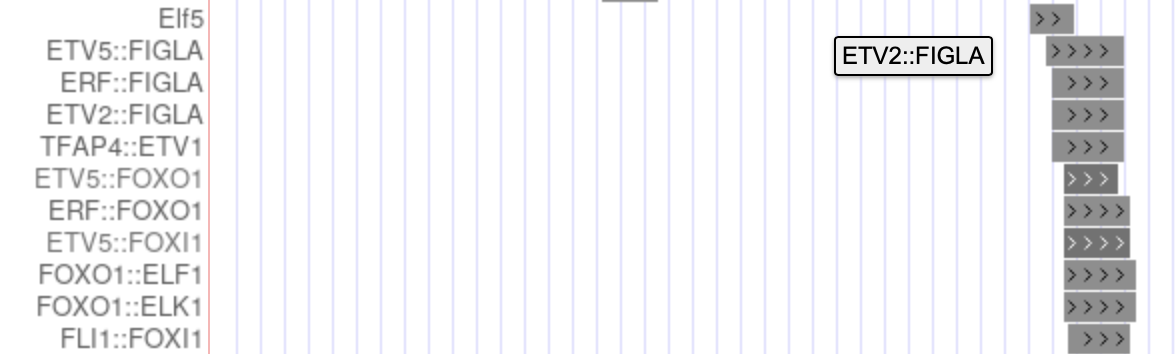

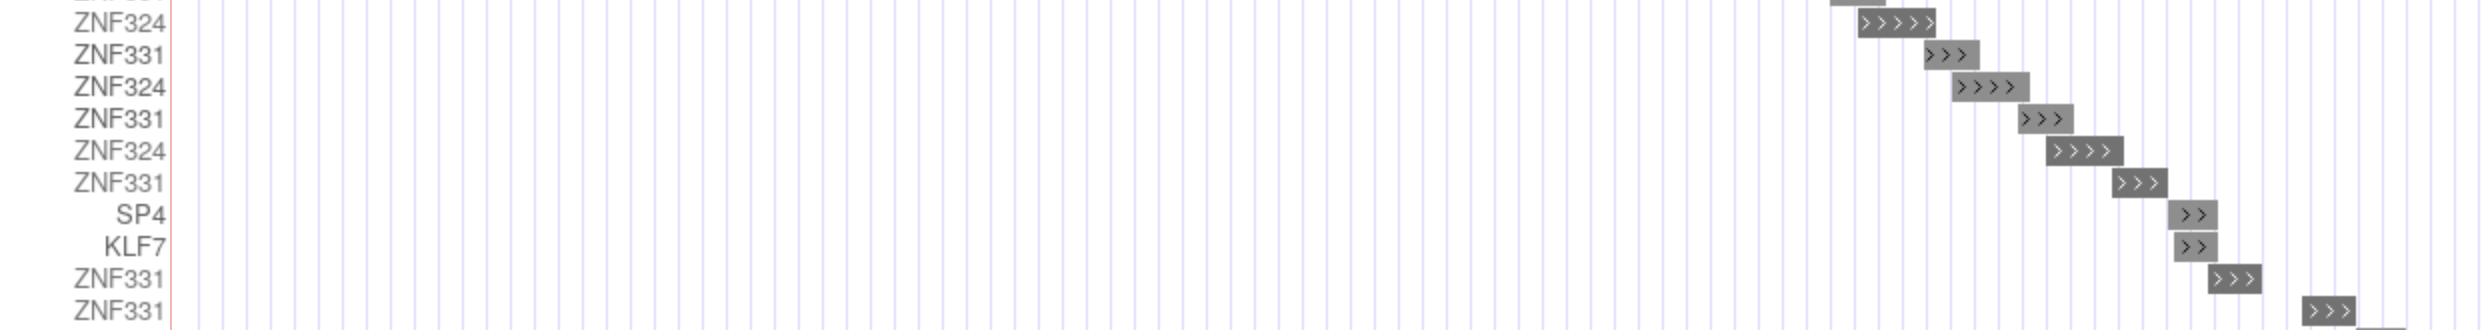

### see if threre are any cells with the unique peak or a peak at the TSS, that do not express IL17f

In [27]:
IL17f_expr = RNA_seq_val[RNA_seq_val.index == "Il17f"].copy()
IL17f_expr

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,1.024819,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.13509,1.017884,1.040295,1.017884,1.021351


In [28]:
IL17f_TSS_ATAC = ATAC_seq_IL17[ATAC_seq_IL17["Summit"] == 20784347].copy()
IL17f_TSS_ATAC

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
14,ImmGenATAC1219.peak_2095,chr1,20784347,0.55,11.49,1.0,Il17f,"Il17a,Il17f,Mcm3",0.41,0.71,...,2.1,1.81,1.14,0.11,1.82,1.94,0.1,1.92,3.39,0.94


In [29]:
IL17f_unique_peak_ATAC = ATAC_seq_IL17[ATAC_seq_IL17["Summit"] == 20744070].copy()
IL17f_unique_peak_ATAC

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
8,ImmGenATAC1219.peak_2086,chr1,20744070,0.0,7.53,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,0.1,...,0.44,0.36,0.11,0.53,0.11,0.56,1.26,0.11,1.04,1.26


test the unique peaks value against to other cell types

In [30]:
import scipy.stats as stats

unique_peak_others = IL17f_unique_peak_ATAC[IL17f_unique_peak_ATAC.columns[8:]].copy()
unique_peak_others = unique_peak_others.drop("Tgd.g2+d17.LN", axis=1)

unique_peak_others = unique_peak_others.melt()["value"].to_list()

In [31]:
t_stat, p_value = stats.ttest_1samp(unique_peak_others, popmean=IL17f_unique_peak_ATAC["Tgd.g2+d17.LN"])
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -279.929504000158
p-value: 1.3310975317788773e-131


- the expression of IL17f seems to be quite promotor driven, because the OCR at the TSS is only active in cell types expressing IL17f (probably not regulated by silencers)
- the peak we found in IL17f expressing Tgd cells is very unique for them and is only slightly active in Treg cells (not producing IL17f), but not in any others
    - the peak value is significantly different from the other ATACseq values at that summit (very low p-value) 

### test if difference in OCRs is significant between Tgd.g2+d17.LN and Tgd.g2+d1.LN aswell as ILC3.NKp46-CCR6-.SI

In [32]:
from scipy.stats import wilcoxon
from scipy.stats import ttest_rel

In [33]:
stat, p = wilcoxon(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["Tgd.g2+d1.LN"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 161.0
p = 0.1459994912147522


In [34]:
stat, p = wilcoxon(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["ILC3.NKp46-CCR6-.SI"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 204.0
p = 0.5698575973510742


In [35]:
stat, p = ttest_rel(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["Tgd.g2+d1.LN"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 2.4046840016438136
p = 0.022795711214076995


In [36]:
stat, p = ttest_rel(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["ILC3.NKp46-CCR6-.SI"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 1.5552372352372033
p = 0.1307365282851432
